# Empirical study notebook

In [1]:
from decision_maker import *
from explainer import estimate_interventional_probability_tabular, UtilityAlignedTabularExplainer
from fairlearn.datasets import fetch_acs_income, fetch_adult
import graphviz
from IPython.display import Image, display
import lime
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
import shap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from ucimlrepo import fetch_ucirepo
from utils import *
from xgboost import XGBClassifier

/home/alexis/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RANDOM_SEED = 42
used_seeds = [RANDOM_SEED, 2026, 2110]

def evaluate_models(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    y_prob = model.predict_proba(X_test) 
    
    accuracy = accuracy_score(y_test, y_pred)
    
    logloss = log_loss(y_test, y_prob)
    
    if len(np.unique(y_test)) > 2:
        roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
    else:
        roc_auc = roc_auc_score(y_test, y_prob[:, 1])
        
    return accuracy, -logloss, roc_auc

def model_performance(model, X_test, y_test):
    accuracy, logloss, roc_auc = evaluate_models(model, X_test, y_test)
    return {
        "accuracy": accuracy,
        "logloss": -logloss,
        "roc_auc": roc_auc
    }

## Loan Approval dataset

In [3]:
# Loan Approval dataset
loan_df = pd.read_csv("./LoanApproval.csv")
loan_df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [4]:
X_loan = loan_df.drop(columns=["loan_status"])
y_loan = loan_df["loan_status"]

loan_features = X_loan.columns.to_list()
X_train_loan, X_rest_loan, y_train_loan, y_rest_loan = train_test_split(X_loan, y_loan, test_size=0.3, random_state=RANDOM_SEED)
X_val_loan, X_test_loan, y_val_loan, y_test_loan = train_test_split(X_rest_loan, y_rest_loan, test_size=0.5, random_state=RANDOM_SEED)


X_train_loan = X_train_loan.reset_index(drop=True)
X_val_loan = X_val_loan.reset_index(drop=True)
X_test_loan = X_test_loan.reset_index(drop=True)
y_train_loan = y_train_loan.reset_index(drop=True)
y_val_loan = y_val_loan.reset_index(drop=True)
y_test_loan = y_test_loan.reset_index(drop=True)

categorical_cols = X_loan.select_dtypes(include=['object']).columns.tolist()
loan_categorical_indices = [loan_features.index(col) for col in categorical_cols]
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

preprocessor_loan = ColumnTransformer(transformers=[('cat', encoder, categorical_cols)], remainder='passthrough')

X_train_processed_loan = pd.DataFrame(preprocessor_loan.fit_transform(X_train_loan), columns=loan_features, index=X_train_loan.index)
X_val_processed_loan = pd.DataFrame(preprocessor_loan.fit_transform(X_val_loan), columns=loan_features, index=X_val_loan.index)
X_test_processed_loan = pd.DataFrame(preprocessor_loan.transform(X_test_loan), columns=loan_features, index=X_test_loan.index)

loan_class_names = [str(c) for c in sorted(loan_df['loan_status'].unique())]

In [5]:
loan_model = XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss', n_estimators=5000, early_stopping_rounds=100)
loan_model.fit(X_train_processed_loan, y_train_loan, eval_set=[(X_val_processed_loan, y_val_loan)], verbose=False)
model_performance(loan_model, X_test_processed_loan, y_test_loan)

{'accuracy': 0.9268148148148149,
 'logloss': 0.1608621264216013,
 'roc_auc': 0.9758431275710535}

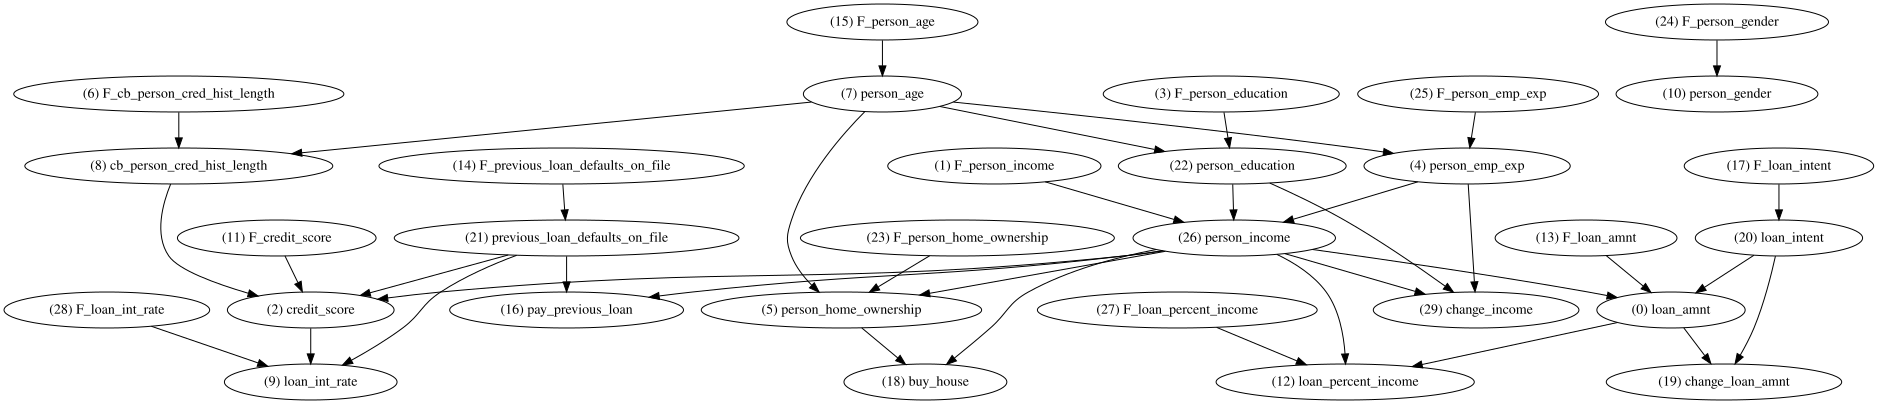

In [6]:
loan_actions = [
    "buy_house",
    "change_loan_amnt", 
    "change_income", 
    "pay_previous_loan"
]

loan_utility_matrix = np.array([
    [-12, 0], # buy_house
    [-1,  0], # change_loan_amnt
    [-12, 0], # change_income
    [-6,  0]  # pay_previous_loan
])

loan_causal = CausalDAG(features=loan_features, actions=loan_actions)

loan_causal.add_causal_edge("person_age", "person_emp_exp")
loan_causal.add_causal_edge("person_age", "cb_person_cred_hist_length")
loan_causal.add_causal_edge("person_age", "person_education")

loan_causal.add_causal_edge("person_education", "person_income")
loan_causal.add_causal_edge("person_emp_exp", "person_income")

loan_causal.add_causal_edge("person_income", "person_home_ownership")
loan_causal.add_causal_edge("person_age", "person_home_ownership")

loan_causal.add_causal_edge("cb_person_cred_hist_length", "credit_score")
loan_causal.add_causal_edge("previous_loan_defaults_on_file", "credit_score")
loan_causal.add_causal_edge("person_income", "credit_score")

loan_causal.add_causal_edge("loan_intent", "loan_amnt")
loan_causal.add_causal_edge("person_income", "loan_amnt")

loan_causal.add_causal_edge("loan_amnt", "loan_percent_income")
loan_causal.add_causal_edge("person_income", "loan_percent_income")

loan_causal.add_causal_edge("credit_score", "loan_int_rate")
loan_causal.add_causal_edge("previous_loan_defaults_on_file", "loan_int_rate")
#loan_causal.add_causal_edge("loan_percent_income", "loan_int_rate")
#loan_causal.add_causal_edge("person_home_ownership", "loan_int_rate")

#loan_causal.add_causal_edge("person_gender", "person_income")

loan_causal.add_causal_edge("person_income", "buy_house")
loan_causal.add_causal_edge("person_home_ownership", "buy_house")

loan_causal.add_causal_edge("loan_amnt", "change_loan_amnt")
loan_causal.add_causal_edge("loan_intent", "change_loan_amnt")

loan_causal.add_causal_edge("person_income", "change_income")
loan_causal.add_causal_edge("person_education", "change_income")
loan_causal.add_causal_edge("person_emp_exp", "change_income")

loan_causal.add_causal_edge("previous_loan_defaults_on_file", "pay_previous_loan")
loan_causal.add_causal_edge("person_income", "pay_previous_loan")

dag = loan_causal.getDAG()
loan_dot = dag.toDot()
loan_graph = graphviz.Source(loan_dot)
display(loan_graph)

### Empirical comparison

In [7]:
loan_lime_explainers = dict()

for seed in used_seeds:
    loan_lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_processed_loan.values,
        feature_names=loan_features,
        class_names=loan_class_names, 
#        categorical_features=loan_categorical_indices,
#        discretize_continuous=False,
        random_state=seed
    )
    loan_lime_explainers[seed] = loan_lime_explainer
loan_shap_explainer = None
if isinstance(loan_model, xgb.XGBClassifier):
    loan_shap_explainer = shap.Explainer(loan_model.predict, X_train_processed_loan)
else:
    loan_shap_explainer = shap.Explainer(loan_model)

loan_tester = ExplainerTester(
    name="loan",
    model=loan_model,
    features=loan_features,
    actions=loan_actions,
    causal_graph=loan_causal,
    utility_matrix=loan_utility_matrix,
    X_train=X_train_processed_loan,
    y_train=y_train_loan,
    X_val=X_val_processed_loan,
    y_val=y_val_loan,
    X_test=X_test_processed_loan,
    lime_explainers=loan_lime_explainers,
    shap_explainer=loan_shap_explainer,
    n_samples=20 
)

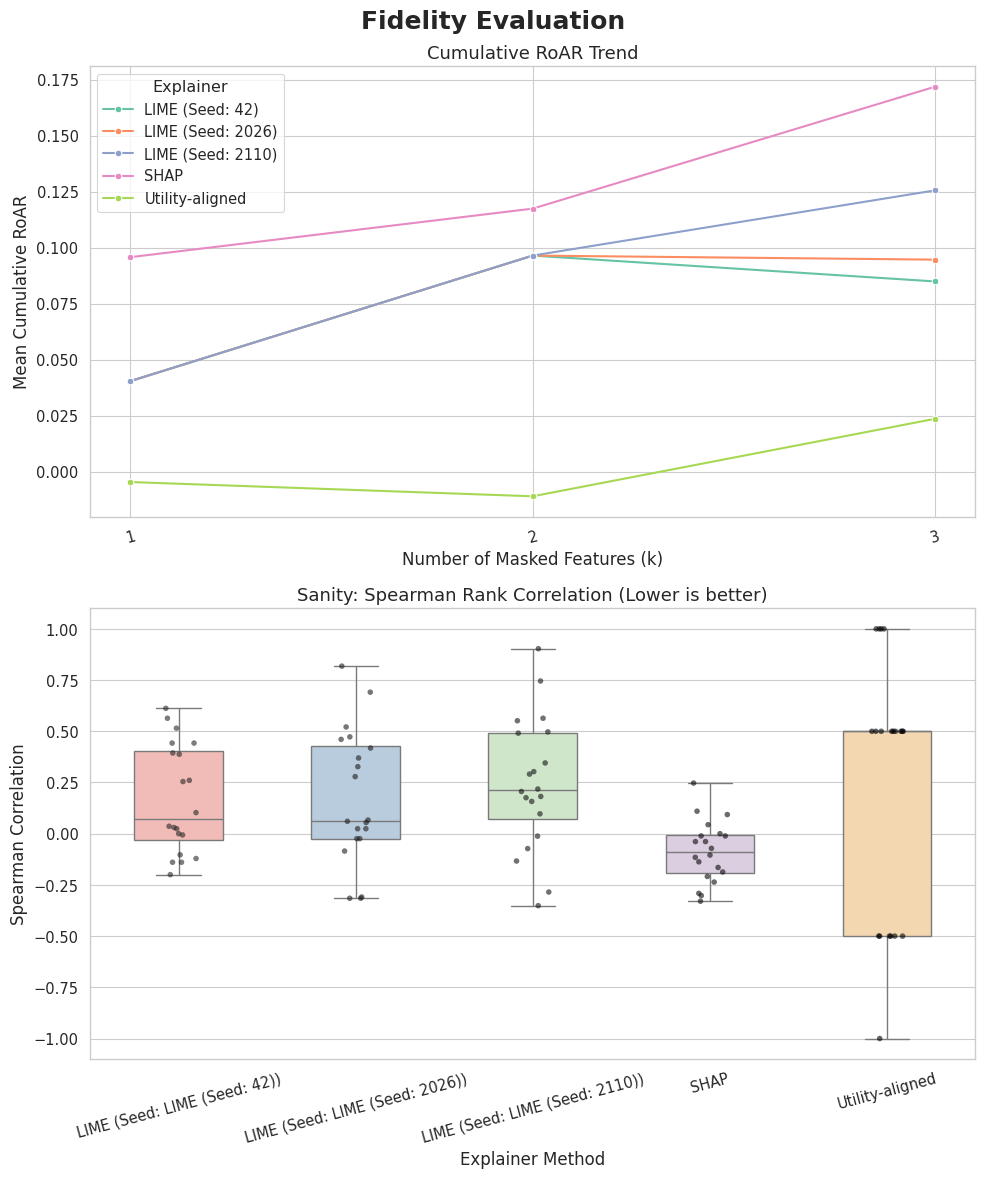

/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, p

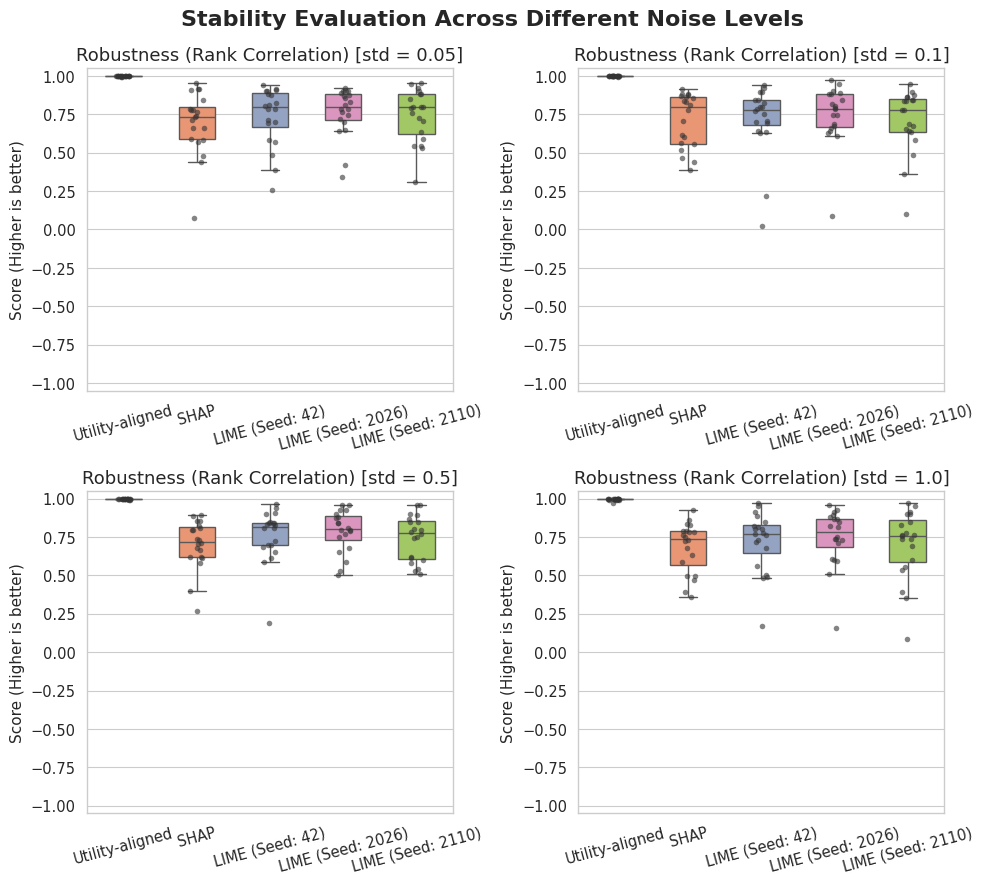

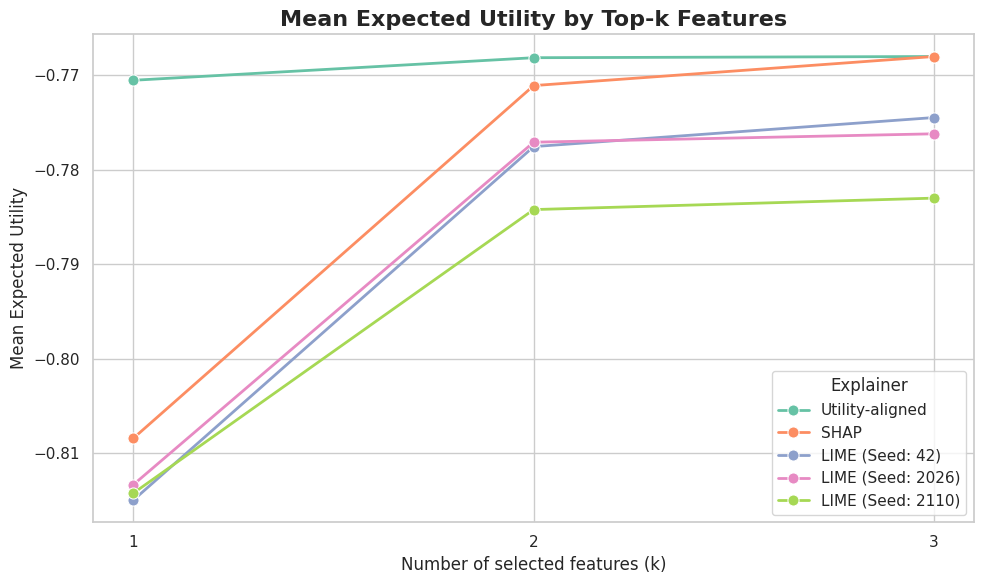

In [8]:
graph_data_loan = loan_tester.do_all_tests(display_test=True)

## Adult Income dataset

In [9]:
X_adult, y_adult = shap.datasets.adult()
X_adult.columns = X_adult.columns.str.replace(r'[\s\-]+', '_', regex=True)
X_adult = X_adult.astype(float)
y_adult = y_adult.astype(int)

In [10]:
X_adult

,Age,Workclass,Education_Num,Marital_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_per_week,Country
0,39.0,7.0,13.0,4.0,1.0,0.0,4.0,1.0,2174.0,0.0,40.0,39.0
1,50.0,6.0,13.0,2.0,4.0,4.0,4.0,1.0,0.0,0.0,13.0,39.0
2,38.0,4.0,9.0,0.0,6.0,0.0,4.0,1.0,0.0,0.0,40.0,39.0
3,53.0,4.0,7.0,2.0,6.0,4.0,2.0,1.0,0.0,0.0,40.0,39.0
4,28.0,4.0,13.0,2.0,10.0,5.0,2.0,0.0,0.0,0.0,40.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27.0,4.0,12.0,2.0,13.0,5.0,4.0,0.0,0.0,0.0,38.0,39.0
32557,40.0,4.0,9.0,2.0,7.0,4.0,4.0,1.0,0.0,0.0,40.0,39.0
32558,58.0,4.0,9.0,6.0,1.0,1.0,4.0,0.0,0.0,0.0,40.0,39.0
32559,22.0,4.0,9.0,4.0,1.0,3.0,4.0,1.0,0.0,0.0,20.0,39.0


In [11]:
adult_features = X_adult.columns.to_list()
X_train_adult, X_rest_adult, y_train_adult, y_rest_adult = train_test_split(X_adult, y_adult, test_size=0.3, random_state=RANDOM_SEED)
X_val_adult, X_test_adult, y_val_adult, y_test_adult = train_test_split(X_rest_adult, y_rest_adult, test_size=0.5, random_state=RANDOM_SEED)

X_train_adult = X_train_adult.reset_index(drop=True)
X_val_adult = X_val_adult.reset_index(drop=True)
X_test_adult = X_test_adult.reset_index(drop=True)

adult_model = XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss', n_estimators=5000, early_stopping_rounds=100)
adult_model.fit(X_train_adult, y_train_adult, eval_set=[(X_val_adult, y_val_adult)], verbose=False)

adult_class_names = np.unique(y_adult)

model_performance(adult_model, X_test_adult, y_test_adult)

{'accuracy': 0.8734902763561925,
 'logloss': 0.2783748243932561,
 'roc_auc': 0.9246042444881751}

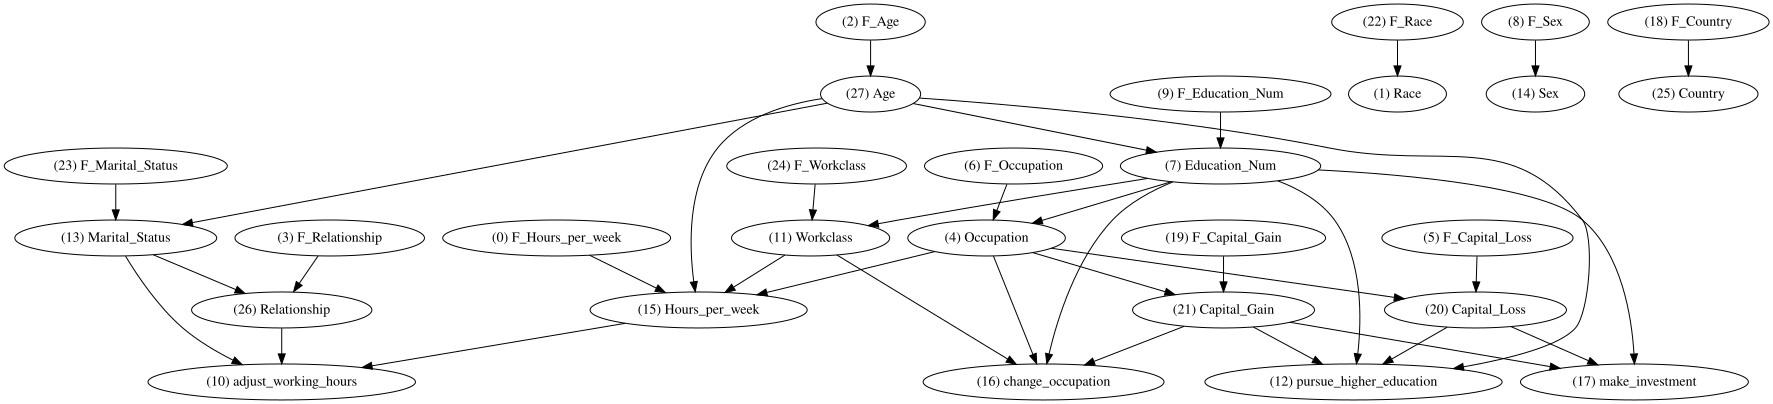

In [12]:
adult_actions = [
    'pursue_higher_education',
    'change_occupation',
    'adjust_working_hours',
    'make_investment'
]

adult_utility_matrix = np.array([
    [2, 8],  # pursue_higher_education
    [3, 6],  # change_occupation
    [4, 5],  # adjust_working_hours
    [1, 7]   # make_investment
])

adult_causal = CausalDAG(features=adult_features, actions=adult_actions)

adult_causal.add_causal_edge('Age', 'Education_Num')
adult_causal.add_causal_edge('Age', 'Marital_Status')
adult_causal.add_causal_edge('Age', 'Hours_per_week')

#adult_causal.add_causal_edge('Country', 'Education_Num')
#adult_causal.add_causal_edge('Race', 'Education_Num')
#adult_causal.add_causal_edge('Sex', 'Occupation')

adult_causal.add_causal_edge('Education_Num', 'Occupation')
adult_causal.add_causal_edge('Education_Num', 'Workclass')

adult_causal.add_causal_edge('Marital_Status', 'Relationship')

adult_causal.add_causal_edge('Occupation', 'Hours_per_week')
adult_causal.add_causal_edge('Occupation', 'Capital_Gain')
adult_causal.add_causal_edge('Occupation', 'Capital_Loss')

#adult_causal.add_causal_edge('Race', 'Workclass')

adult_causal.add_causal_edge('Workclass', 'Hours_per_week')

adult_causal.add_causal_edge('Age', 'pursue_higher_education')
adult_causal.add_causal_edge('Education_Num', 'pursue_higher_education')
adult_causal.add_causal_edge('Capital_Gain', 'pursue_higher_education')
adult_causal.add_causal_edge('Capital_Loss', 'pursue_higher_education')

adult_causal.add_causal_edge('Occupation', 'change_occupation')
adult_causal.add_causal_edge('Education_Num', 'change_occupation')
adult_causal.add_causal_edge('Workclass', 'change_occupation')
adult_causal.add_causal_edge('Capital_Gain', 'change_occupation')

adult_causal.add_causal_edge('Hours_per_week', 'adjust_working_hours')
adult_causal.add_causal_edge('Marital_Status', 'adjust_working_hours')
adult_causal.add_causal_edge('Relationship', 'adjust_working_hours')

adult_causal.add_causal_edge('Capital_Gain', 'make_investment')
adult_causal.add_causal_edge('Capital_Loss', 'make_investment')
adult_causal.add_causal_edge('Education_Num', 'make_investment')

dag = adult_causal.getDAG()
adult_dot = dag.toDot()
adult_graph = graphviz.Source(adult_dot)

display(adult_graph)

In [13]:
adult_lime_explainers = dict()

for seed in used_seeds:
    adult_lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_adult.values,
        feature_names=adult_features,
        class_names=adult_class_names, 
#        categorical_features=adult_categorical_indices,
#        discretize_continuous=False,
        random_state=seed
    )
    adult_lime_explainers[seed] = adult_lime_explainer
if isinstance(adult_model, xgb.XGBClassifier):
    adult_shap_explainer = shap.Explainer(adult_model.predict, X_train_adult)
else:
    adult_shap_explainer = shap.Explainer(adult_model)

adult_tester = ExplainerTester(
    name="adult",
    model=adult_model,
    features=adult_features,
    actions=adult_actions,
    causal_graph=adult_causal,
    utility_matrix=adult_utility_matrix,
    X_train=X_train_adult,
    y_train=y_train_adult,
    X_val=X_val_adult,
    y_val=y_val_adult,
    X_test=X_test_adult,
    lime_explainers=adult_lime_explainers,
    shap_explainer=adult_shap_explainer,
    n_samples=20 
)

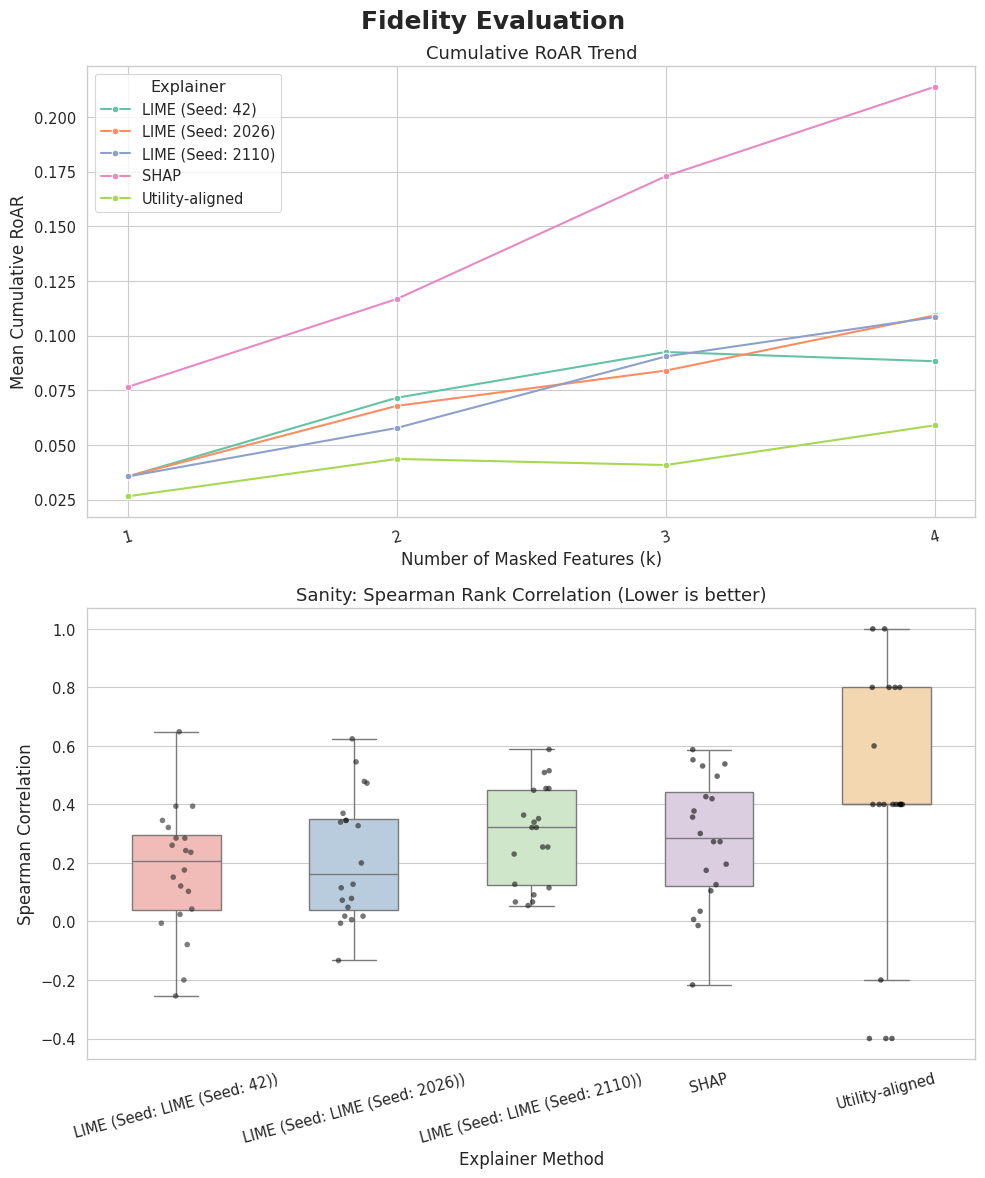

/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, p

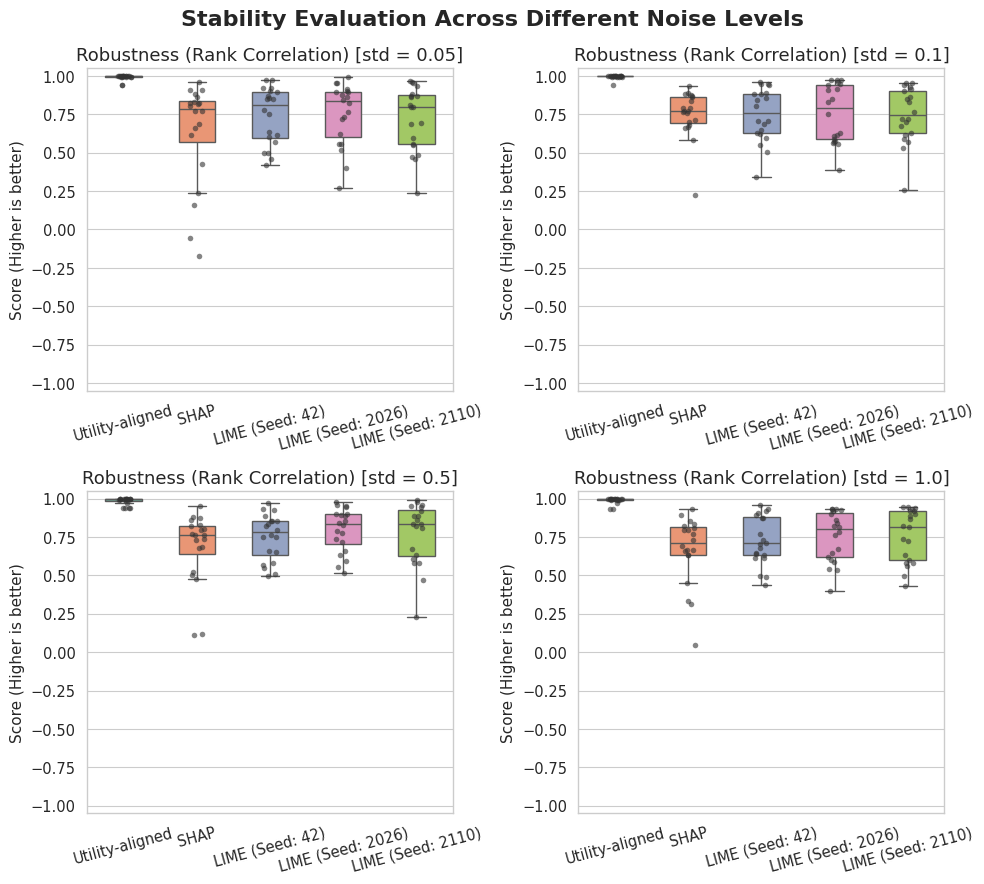

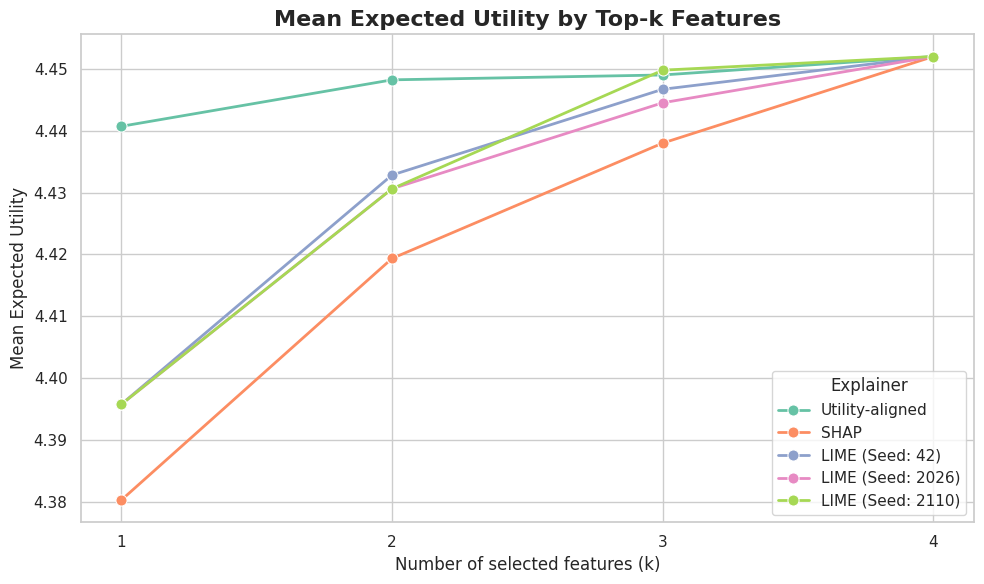

In [14]:
graph_data_adult = adult_tester.do_all_tests(display_test=True)

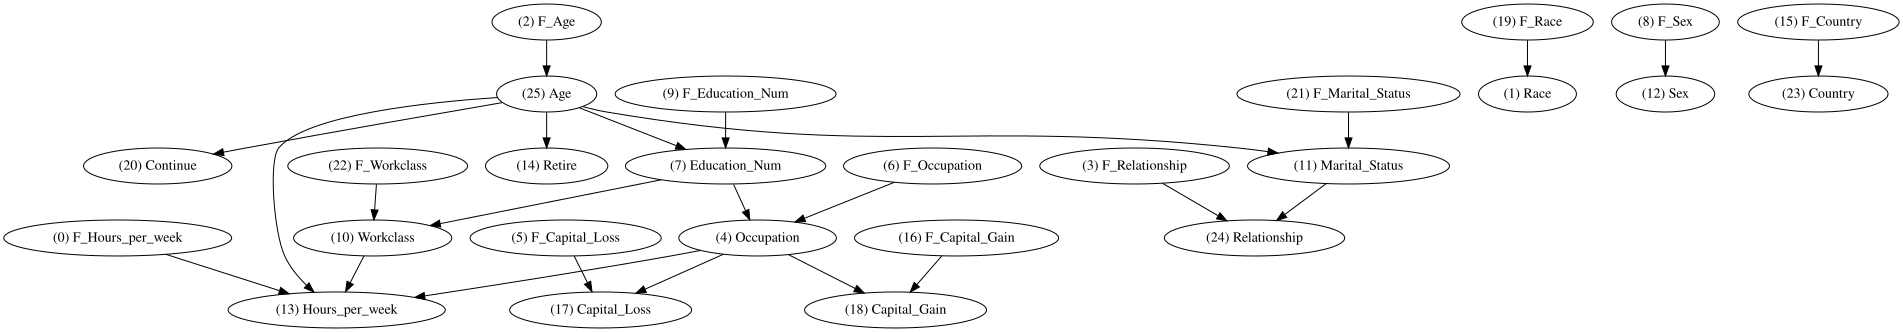

In [15]:
adult_actions_2 = [
    "Retire",
    "Continue"
]

adult_causal_2 = CausalDAG(features=adult_features, actions=adult_actions_2)

adult_causal_2.add_causal_edge('Age', 'Education_Num')
adult_causal_2.add_causal_edge('Age', 'Marital_Status')
adult_causal_2.add_causal_edge('Age', 'Hours_per_week')

#adult_causal.add_causal_edge('Country', 'Education_Num')
#adult_causal.add_causal_edge('Race', 'Education_Num')
#adult_causal.add_causal_edge('Sex', 'Occupation')

adult_causal_2.add_causal_edge('Education_Num', 'Occupation')
adult_causal_2.add_causal_edge('Education_Num', 'Workclass')

adult_causal_2.add_causal_edge('Marital_Status', 'Relationship')

adult_causal_2.add_causal_edge('Occupation', 'Hours_per_week')
adult_causal_2.add_causal_edge('Occupation', 'Capital_Gain')
adult_causal_2.add_causal_edge('Occupation', 'Capital_Loss')

#adult_causal.add_causal_edge('Race', 'Workclass')

adult_causal_2.add_causal_edge('Workclass', 'Hours_per_week')

adult_causal_2.add_causal_edge('Age', 'Retire')
adult_causal_2.add_causal_edge('Age', 'Continue')

dag = adult_causal_2.getDAG()
adult_dot = dag.toDot()
adult_graph = graphviz.Source(adult_dot)

display(adult_graph)

In [ ]:
def generate_adult_utility_matrices(
    n_samples=20,
    seed=42,
    min_margin=0.15
):
    rng = np.random.default_rng(seed)

    # Balanced allocation across scenarios
    base = n_samples // 3
    remainder = n_samples % 3

    counts = {
        "retire_better": base,
        "continue_better": base,
        "symmetric": base
    }

    # Randomly assign remainder instead of always favoring
    # the first scenario(s)
    scenario_names = list(counts.keys())

    if remainder > 0:
        extra_scenarios = rng.choice(
            scenario_names,
            size=remainder,
            replace=False
        )

        for scenario in extra_scenarios:
            counts[scenario] += 1

    samples = []

    def sample_ordered_pair():
        """
        Return (low, high) satisfying:
            high - low >= min_margin
        with both in [0, 1].
        """

        low = rng.uniform(0.0, 1.0 - min_margin)

        high = rng.uniform(
            low + min_margin,
            1.0
        )

        return low, high

    # --------------------------------------------------
    # Scenario 1: Retire always better
    # --------------------------------------------------
    for _ in range(counts["retire_better"]):

        c0, r0 = sample_ordered_pair()
        c1, r1 = sample_ordered_pair()

        matrix = np.array([
            [r0, r1],  # retire
            [c0, c1]   # continue
        ])

        samples.append({
            "scenario": "retire_better",
            "utility_matrix": matrix
        })

    # --------------------------------------------------
    # Scenario 2: Continue always better
    # --------------------------------------------------
    for _ in range(counts["continue_better"]):

        r0, c0 = sample_ordered_pair()
        r1, c1 = sample_ordered_pair()

        matrix = np.array([
            [r0, r1],  # retire
            [c0, c1]   # continue
        ])

        samples.append({
            "scenario": "continue_better",
            "utility_matrix": matrix
        })

    # --------------------------------------------------
    # Scenario 3: Symmetric / outcome-dependent
    #
    # outcome 0 -> Continue preferred
    # outcome 1 -> Retire preferred
    # --------------------------------------------------
    for _ in range(counts["symmetric"]):

        r0, c0 = sample_ordered_pair()  # continue > retire
        c1, r1 = sample_ordered_pair()  # retire > continue

        matrix = np.array([
            [r0, r1],  # retire
            [c0, c1]   # continue
        ])

        samples.append({
            "scenario": "symmetric",
            "utility_matrix": matrix
        })

    # Avoid scenario ordering bias
    rng.shuffle(samples)

    return samples

Running: adult_symmetric_0
Utility matrix:
[[0.40434919 0.84203212]
 [0.65547152 0.5693419 ]]


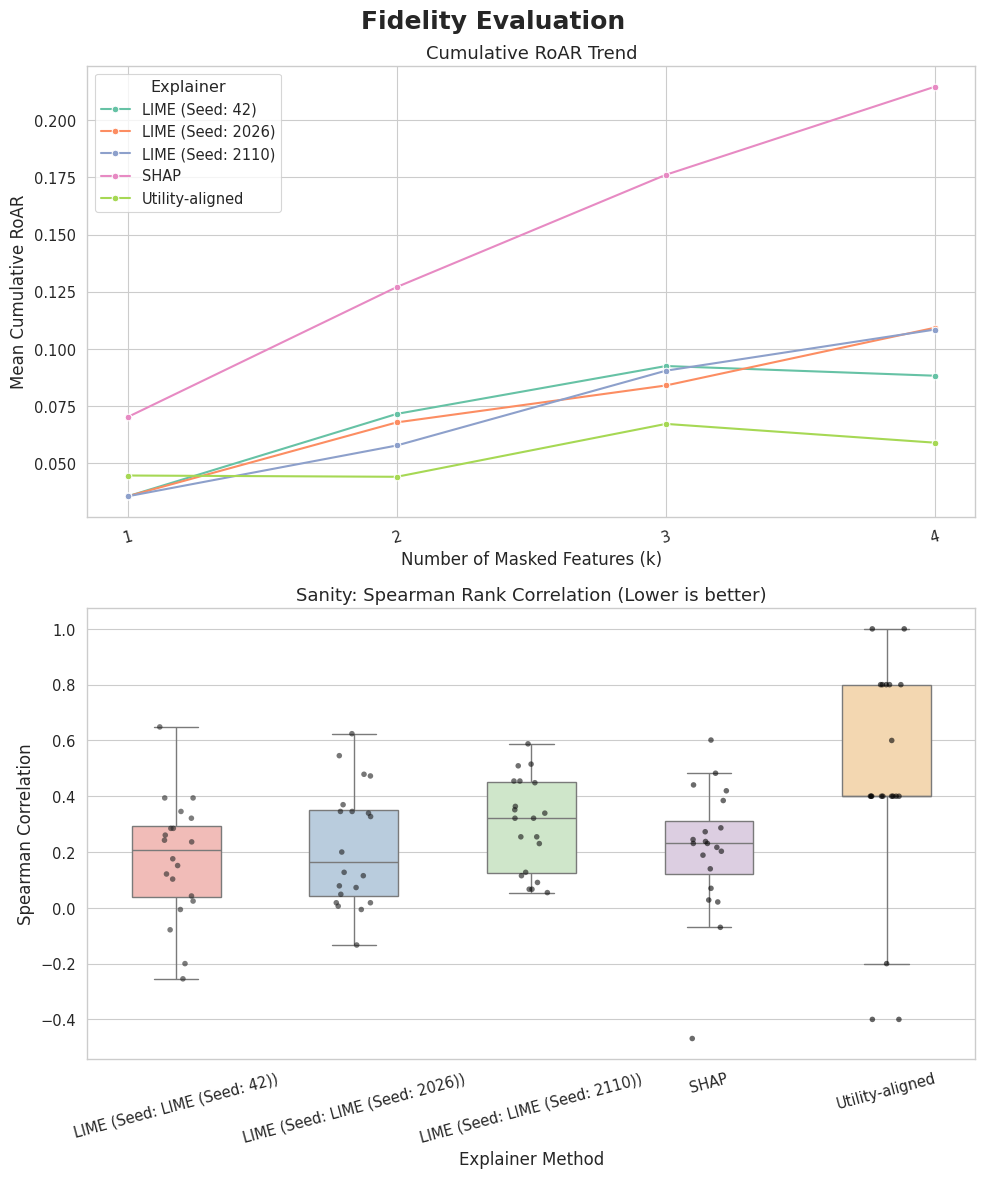

/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, p

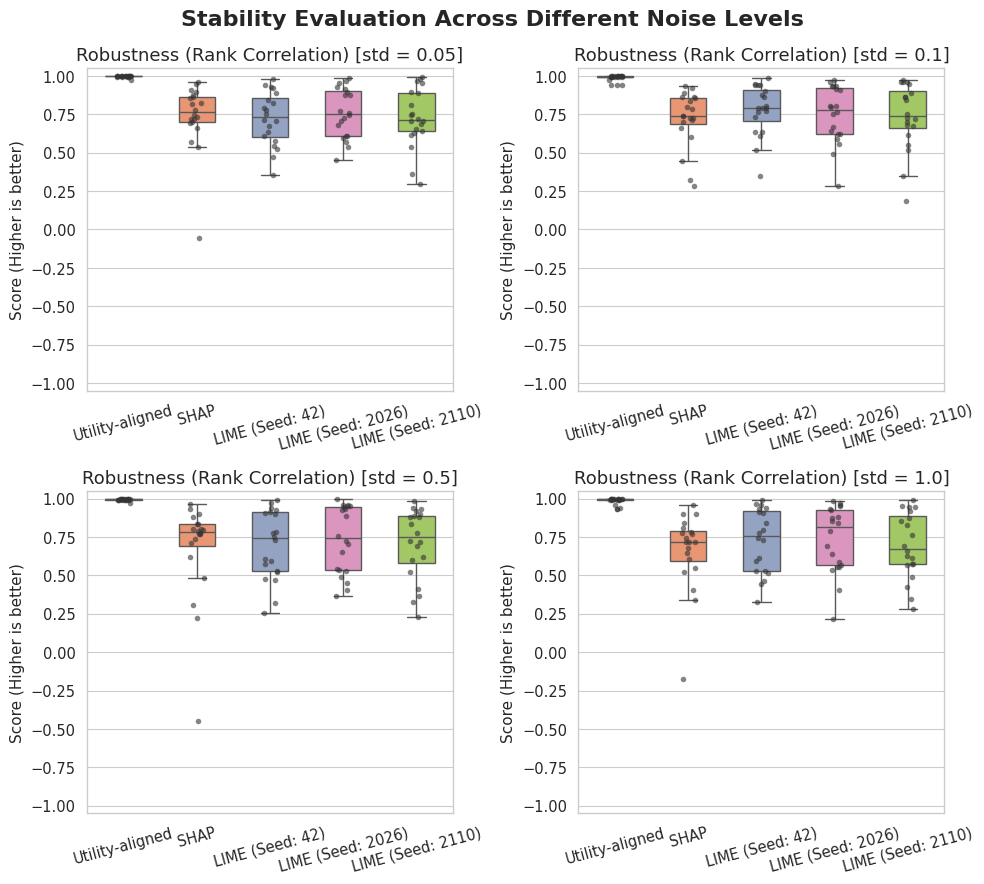

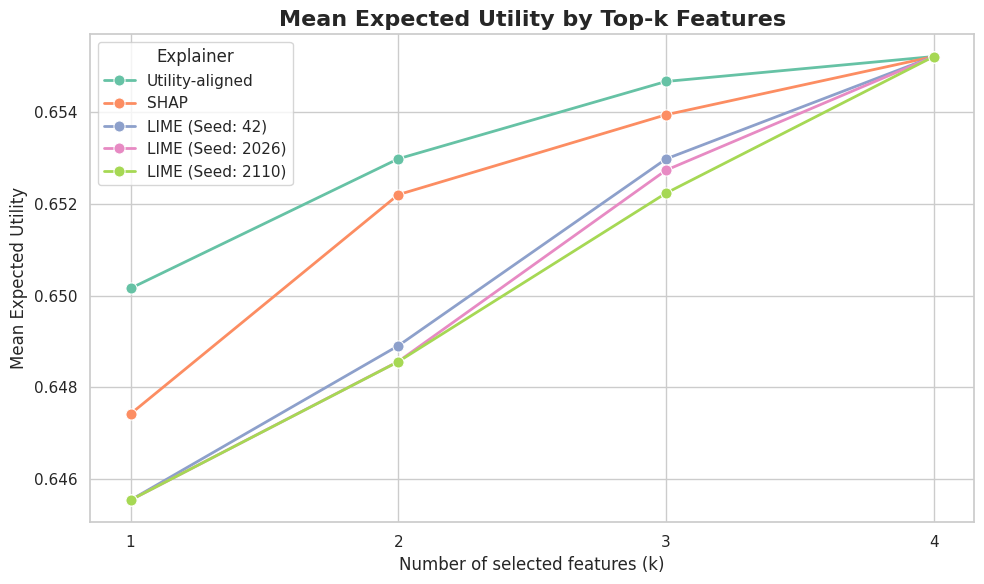

Running: adult_retire_better_0
Utility matrix:
[[0.91614889 0.70743032]
 [0.69934737 0.19315291]]


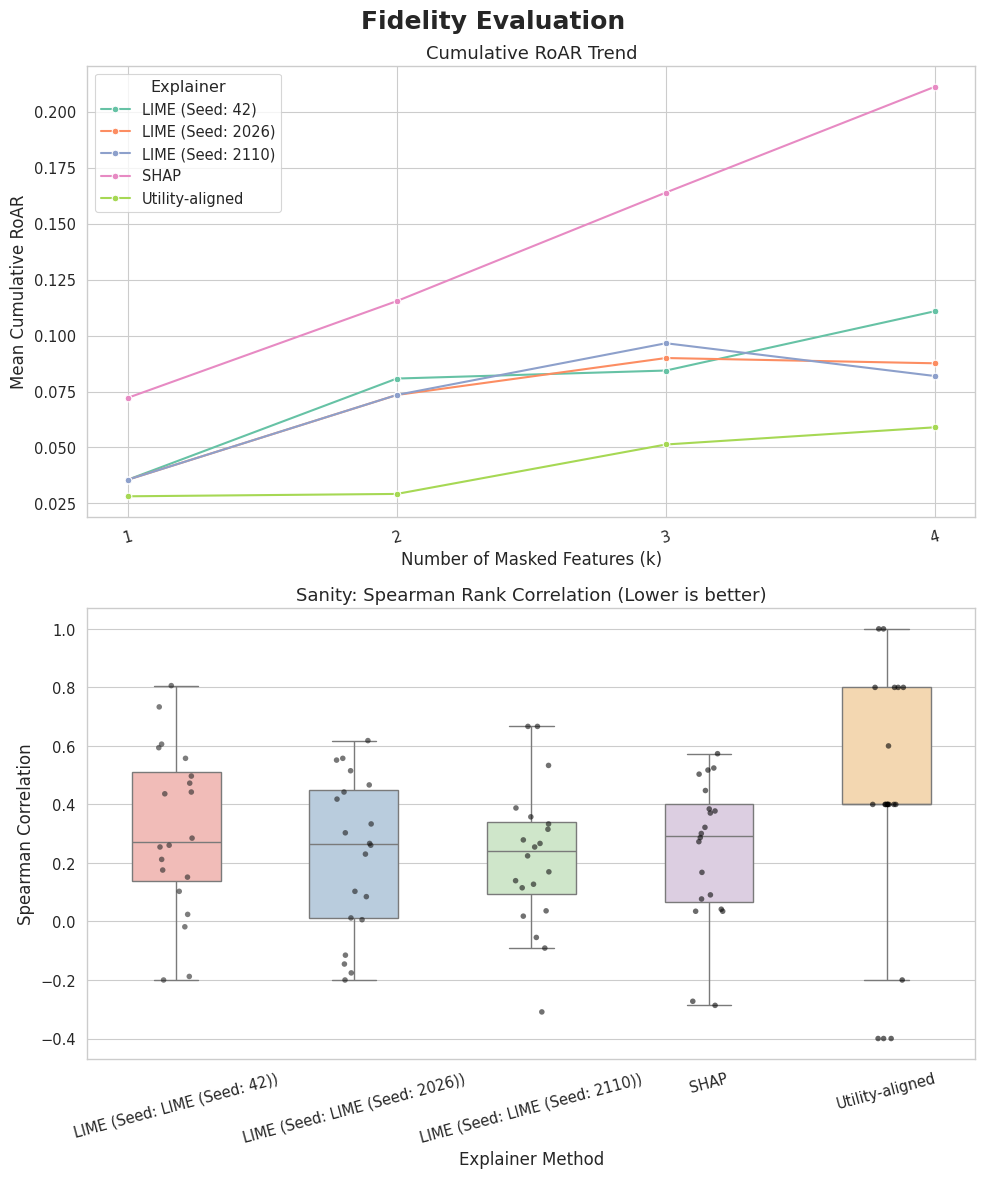

/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, p

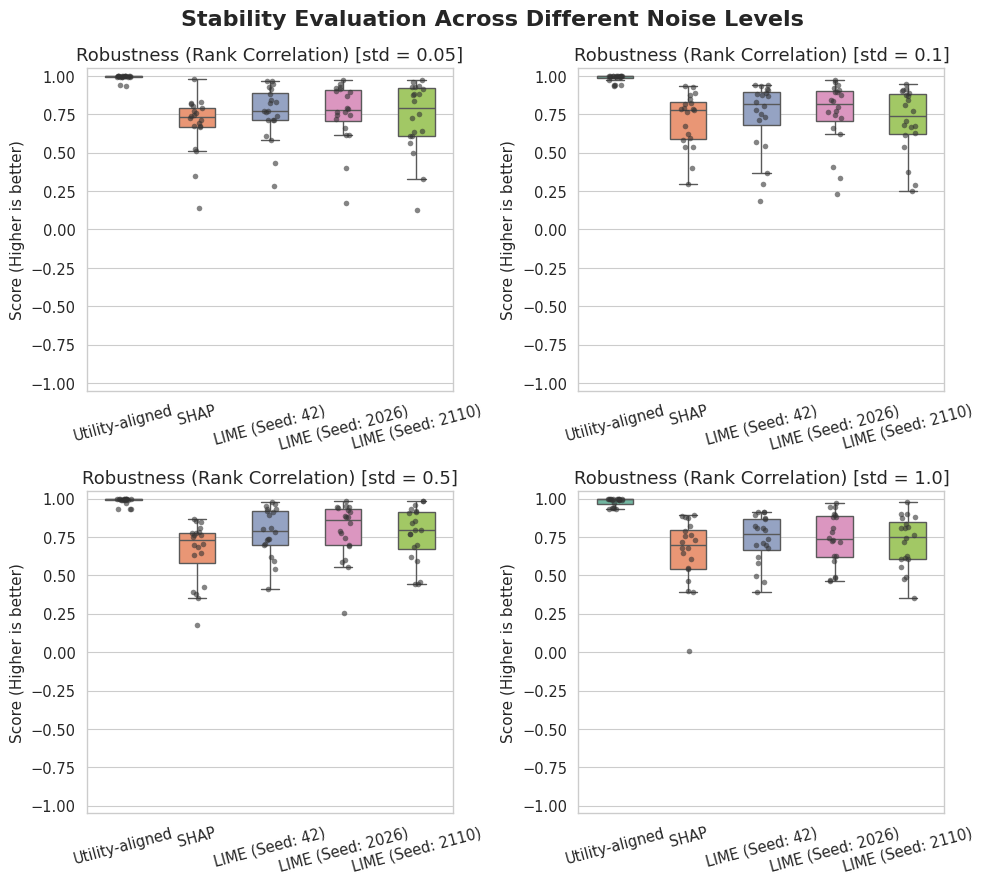

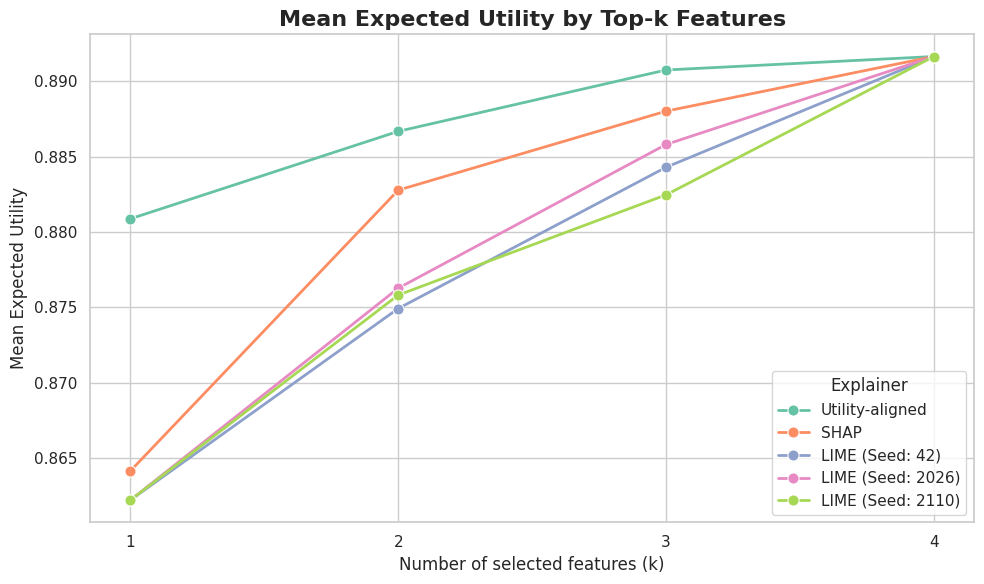

Running: adult_retire_better_1
Utility matrix:
[[0.93255781 0.76698874]
 [0.37304667 0.59276282]]


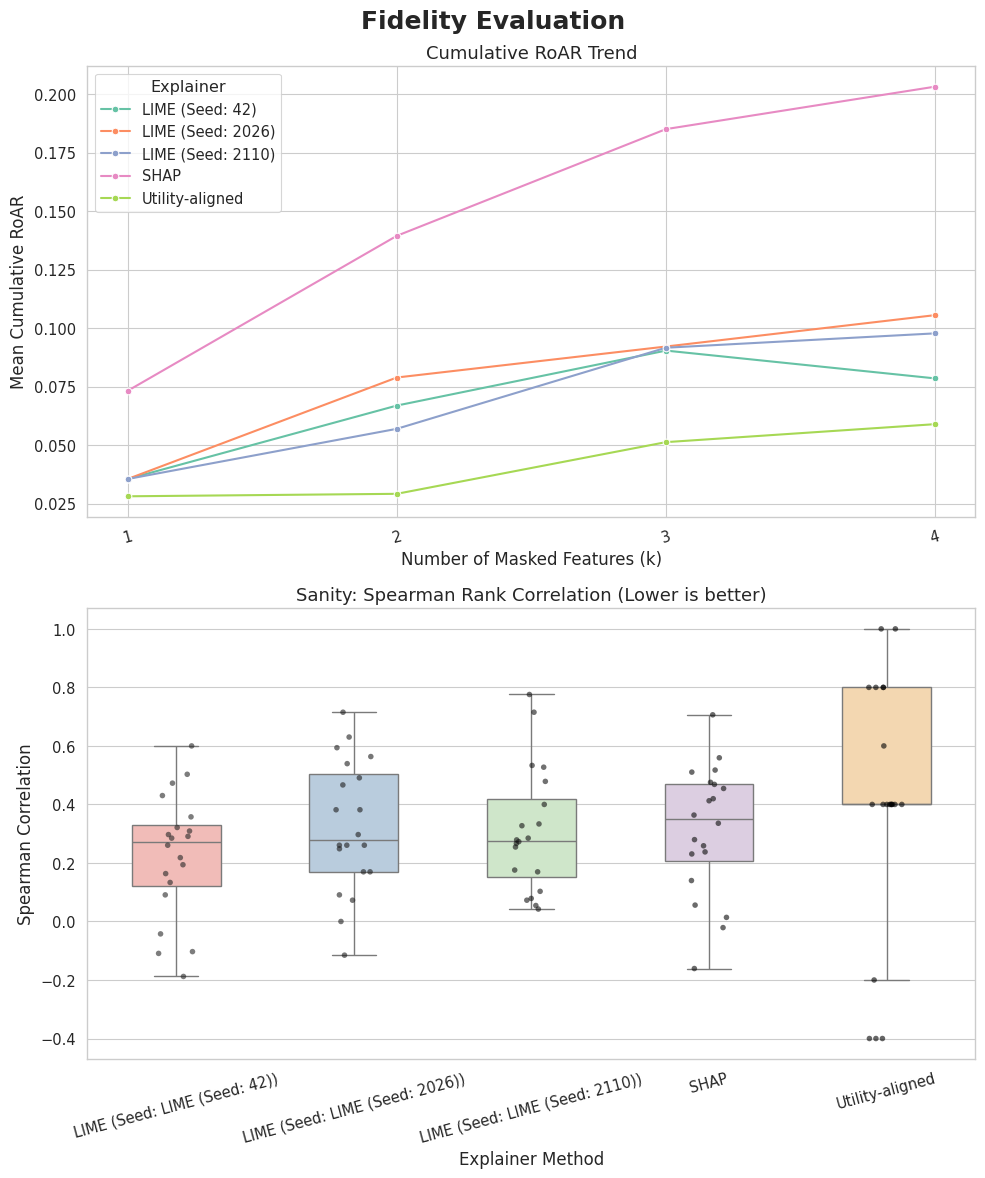

/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, p

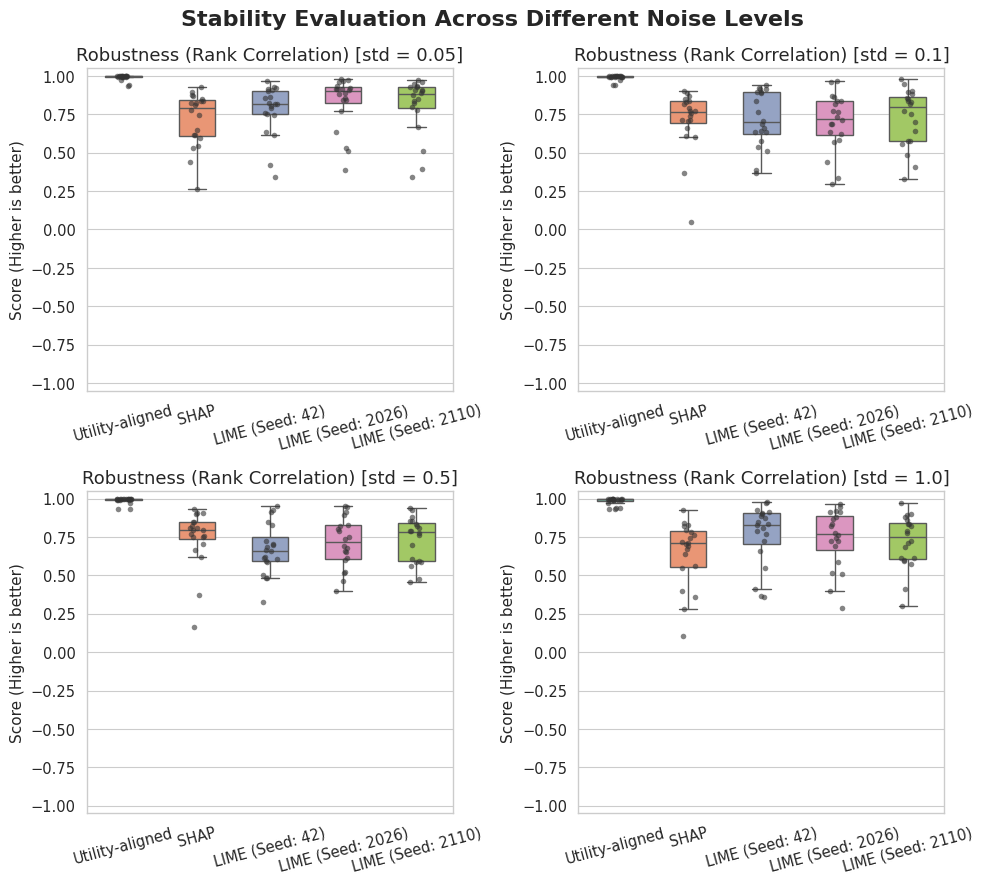

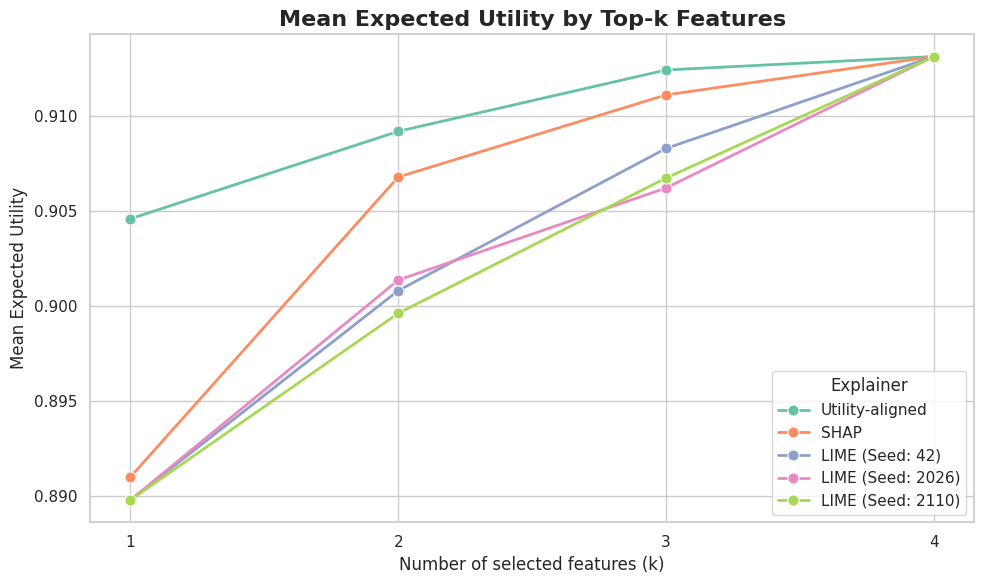

Running: adult_retire_better_2
Utility matrix:
[[0.70605448 0.97783069]
 [0.38282805 0.78775024]]


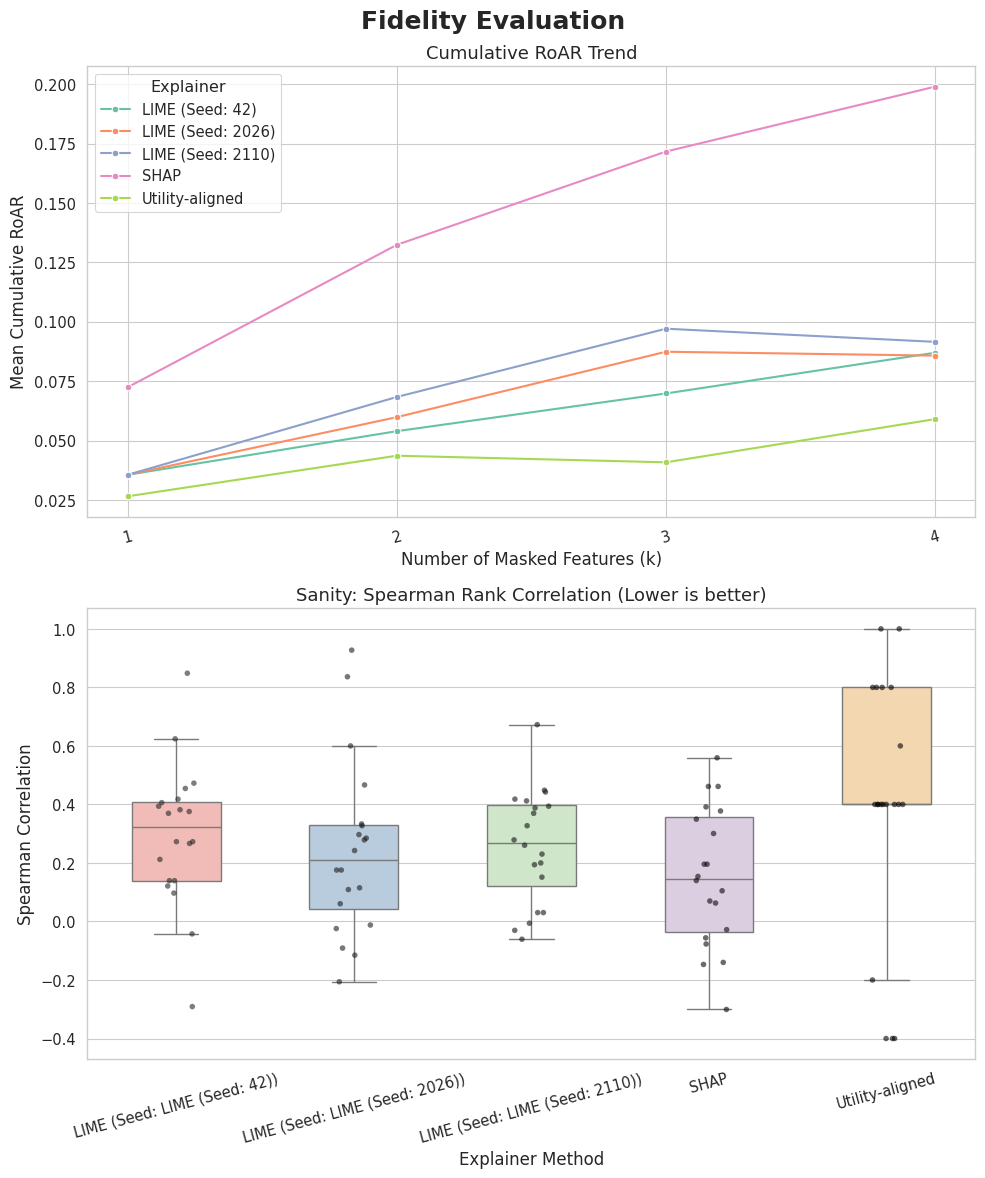

/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, p

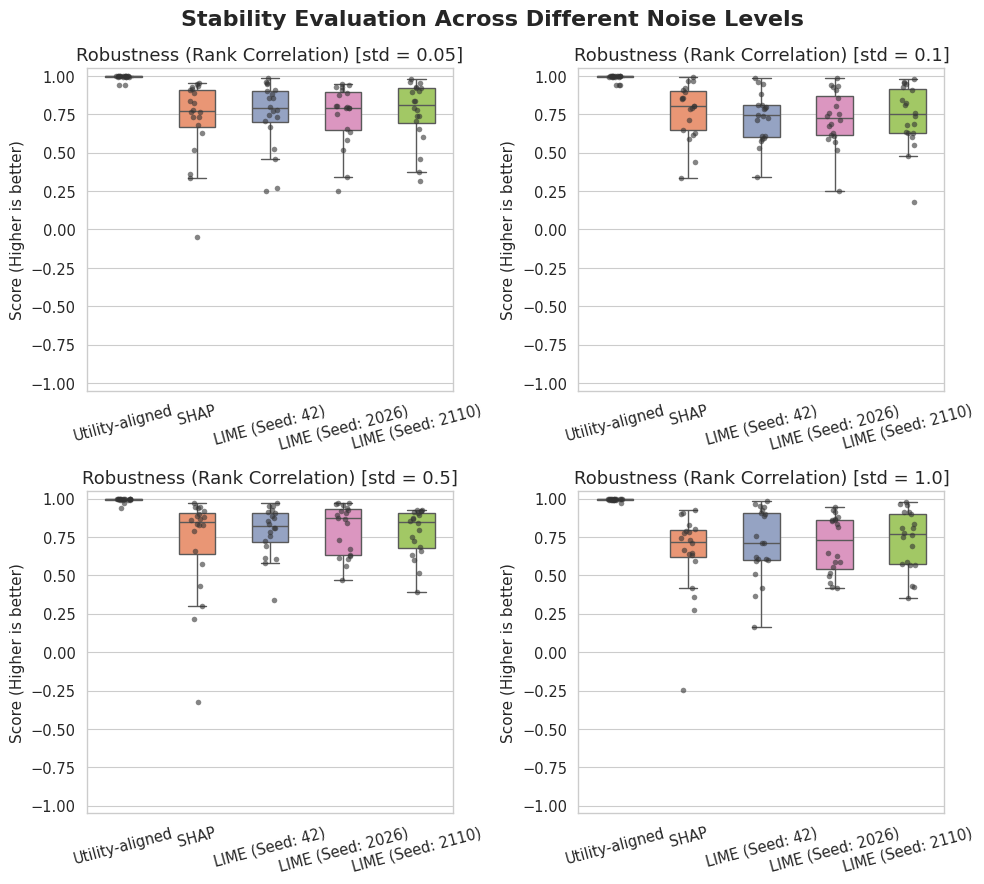

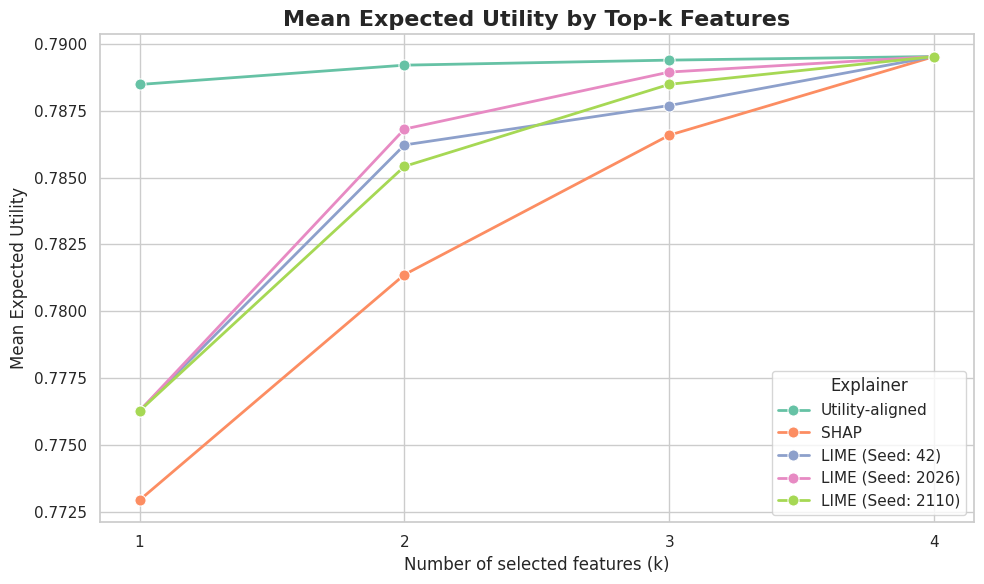

Running: adult_symmetric_1
Utility matrix:
[[0.31489075 0.40055999]
 [0.71615441 0.16105066]]


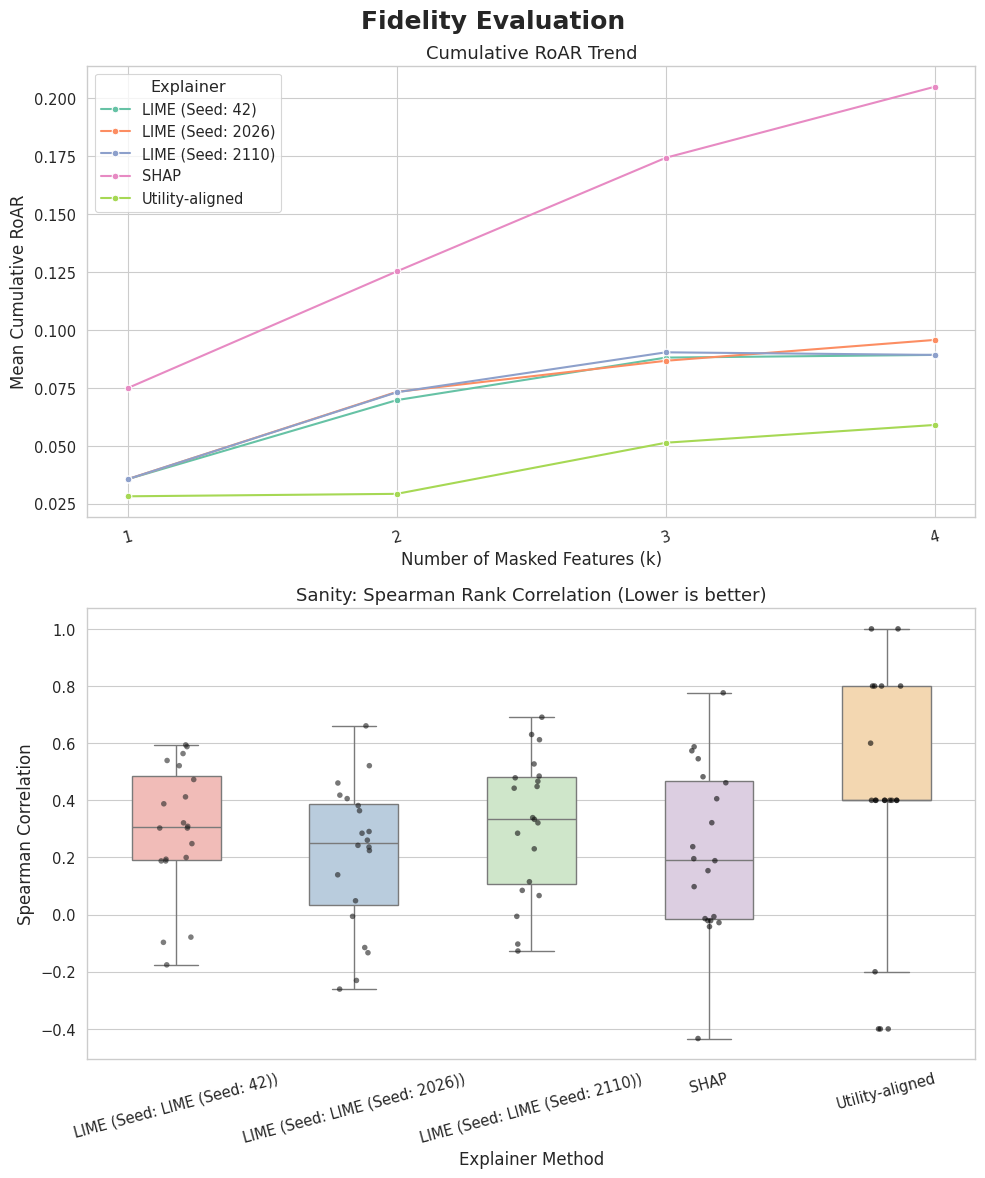

/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, p

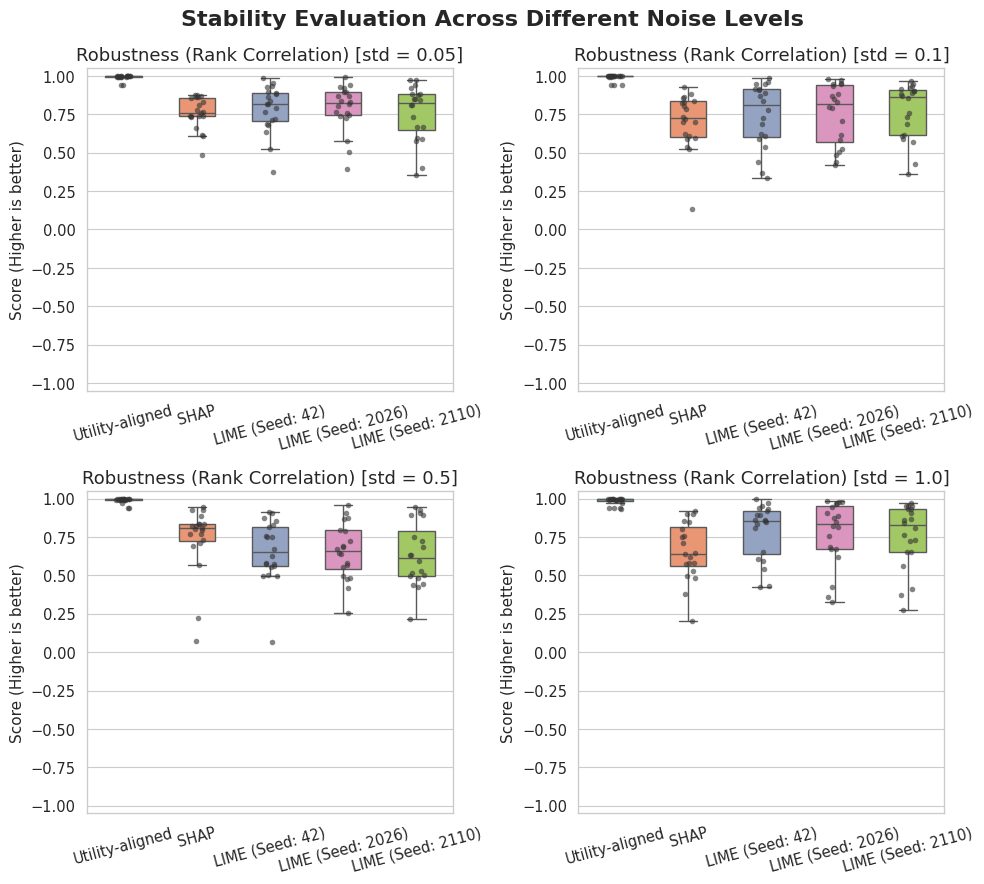

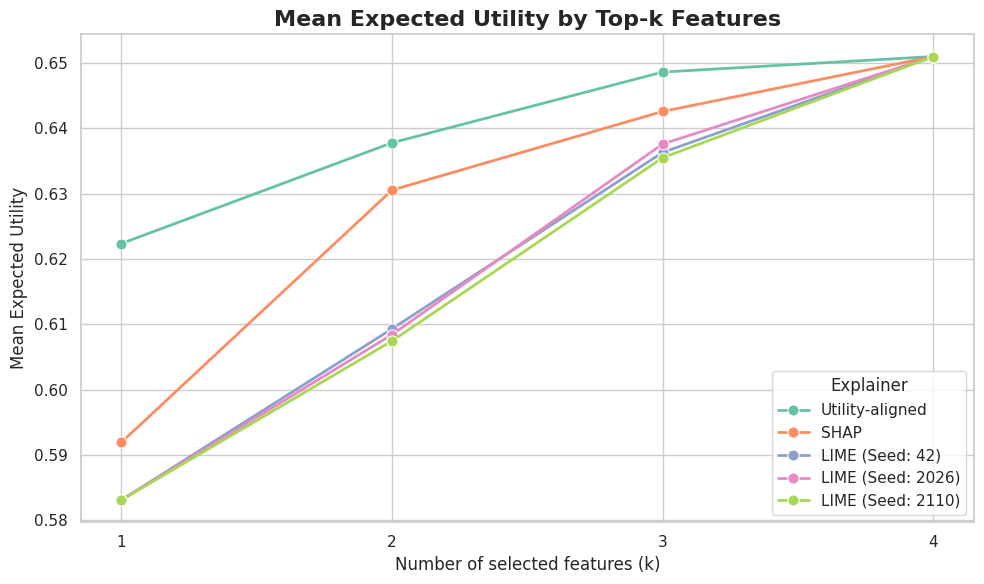

Running: adult_continue_better_0
Utility matrix:
[[0.1654429  0.0372332 ]
 [0.63494008 0.31263458]]


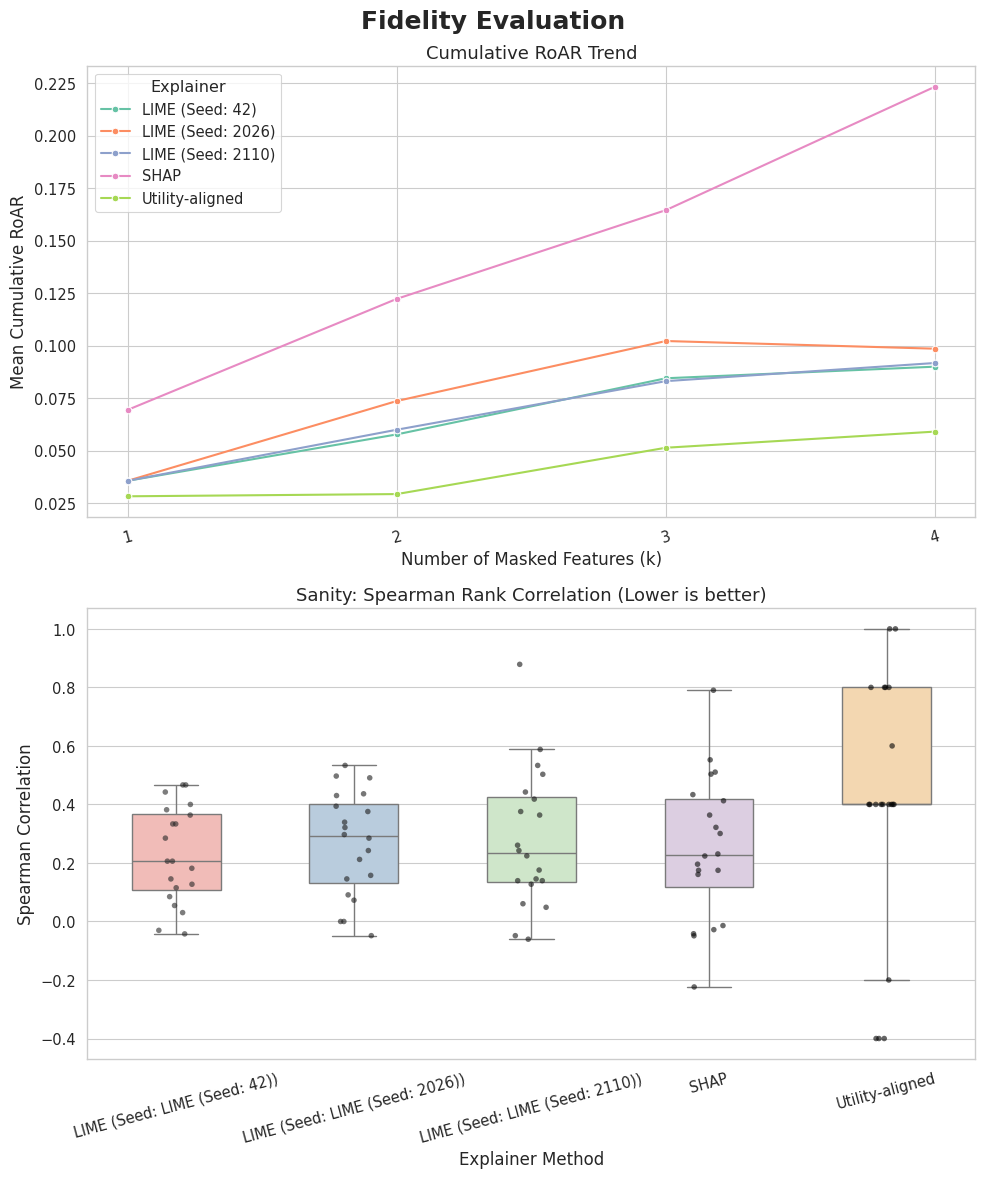

/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, p

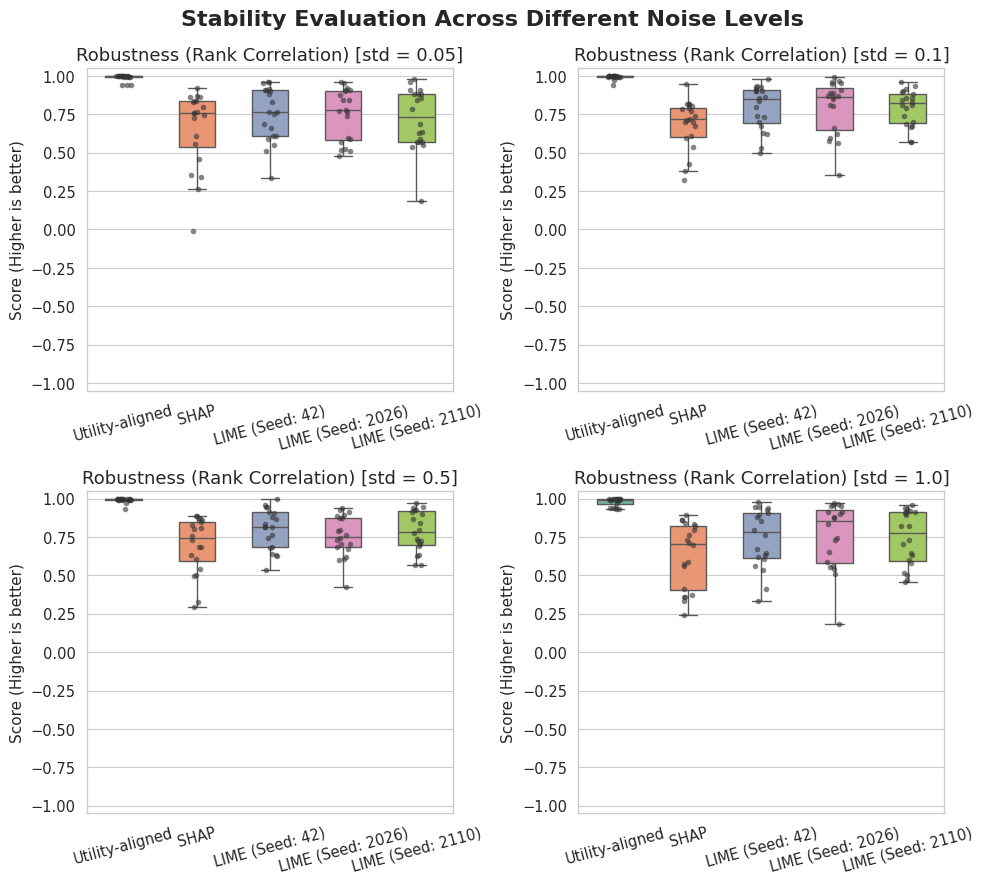

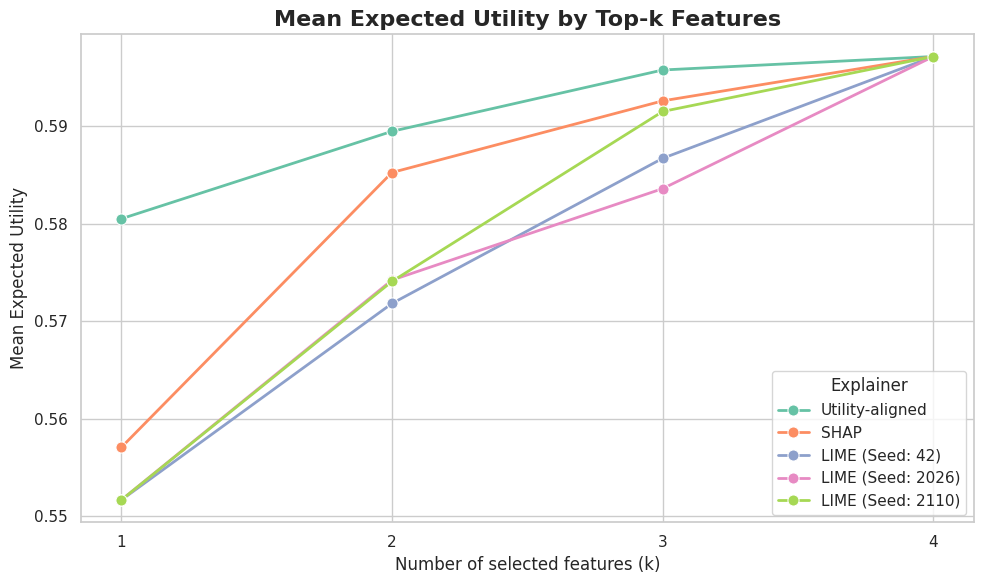

Running: adult_continue_better_1
Utility matrix:
[[0.30134707 0.75915295]
 [0.98392339 0.9798668 ]]


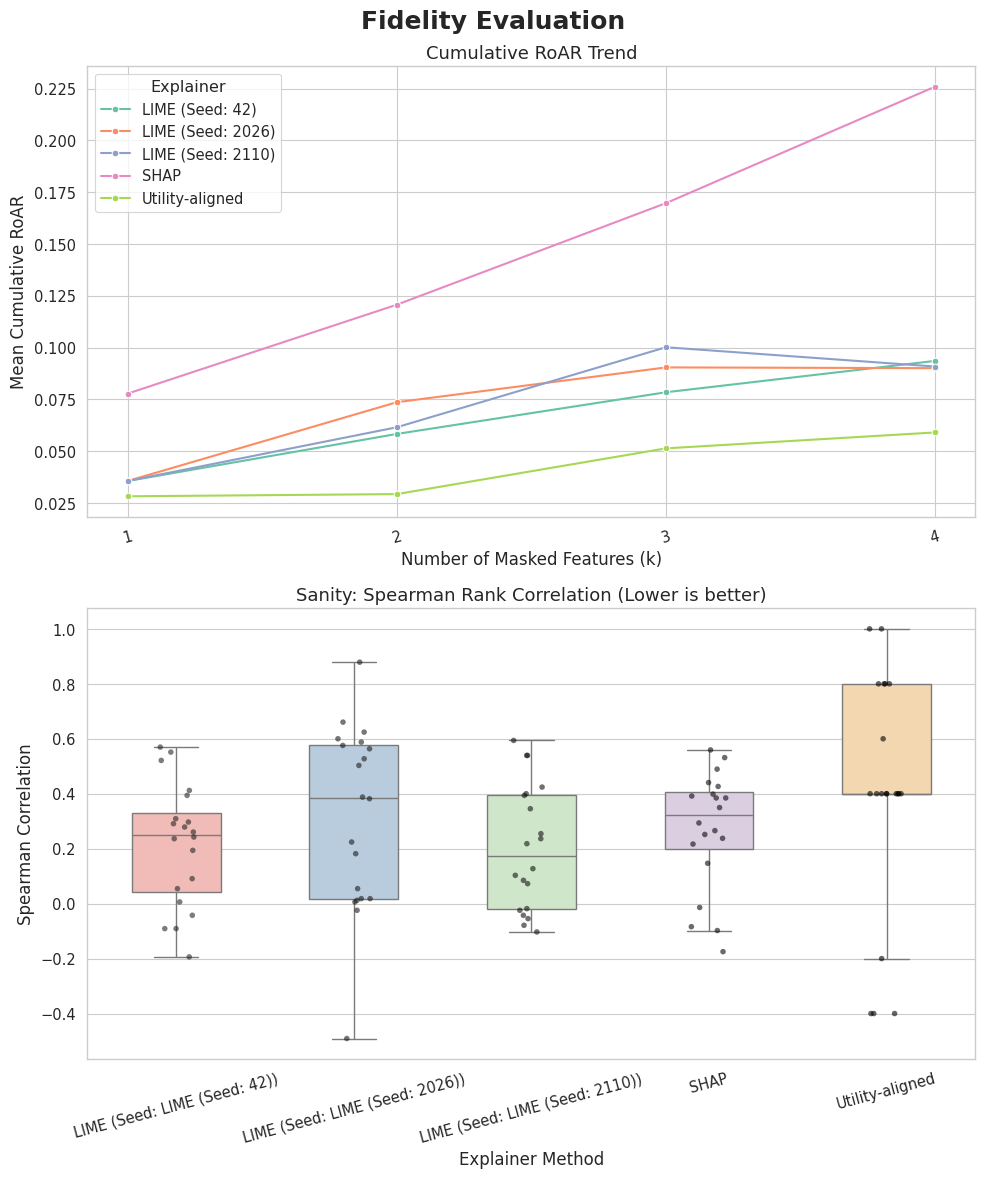

/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, p

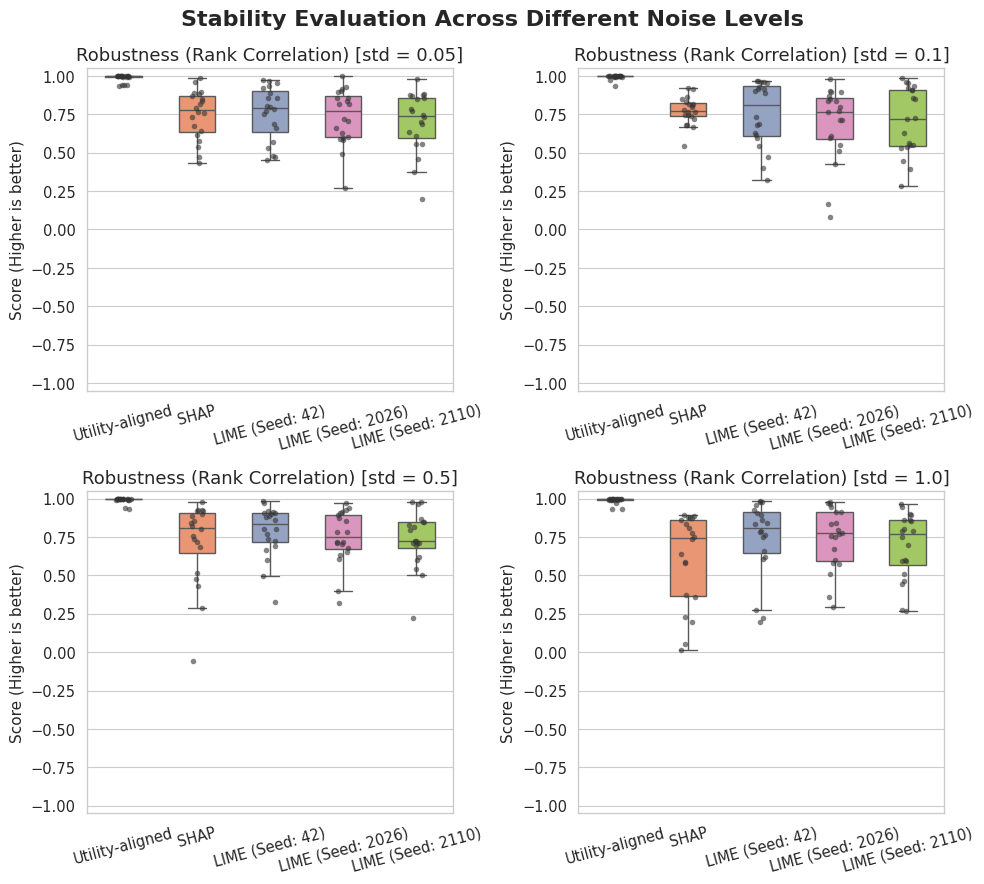

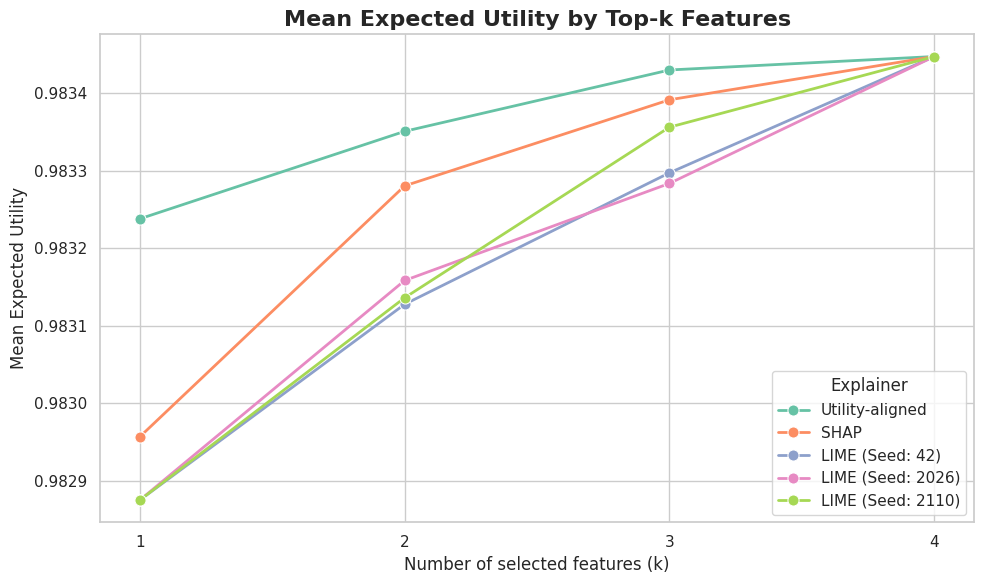

Running: adult_symmetric_2
Utility matrix:
[[0.58059161 0.9813815 ]
 [0.93123678 0.82238327]]


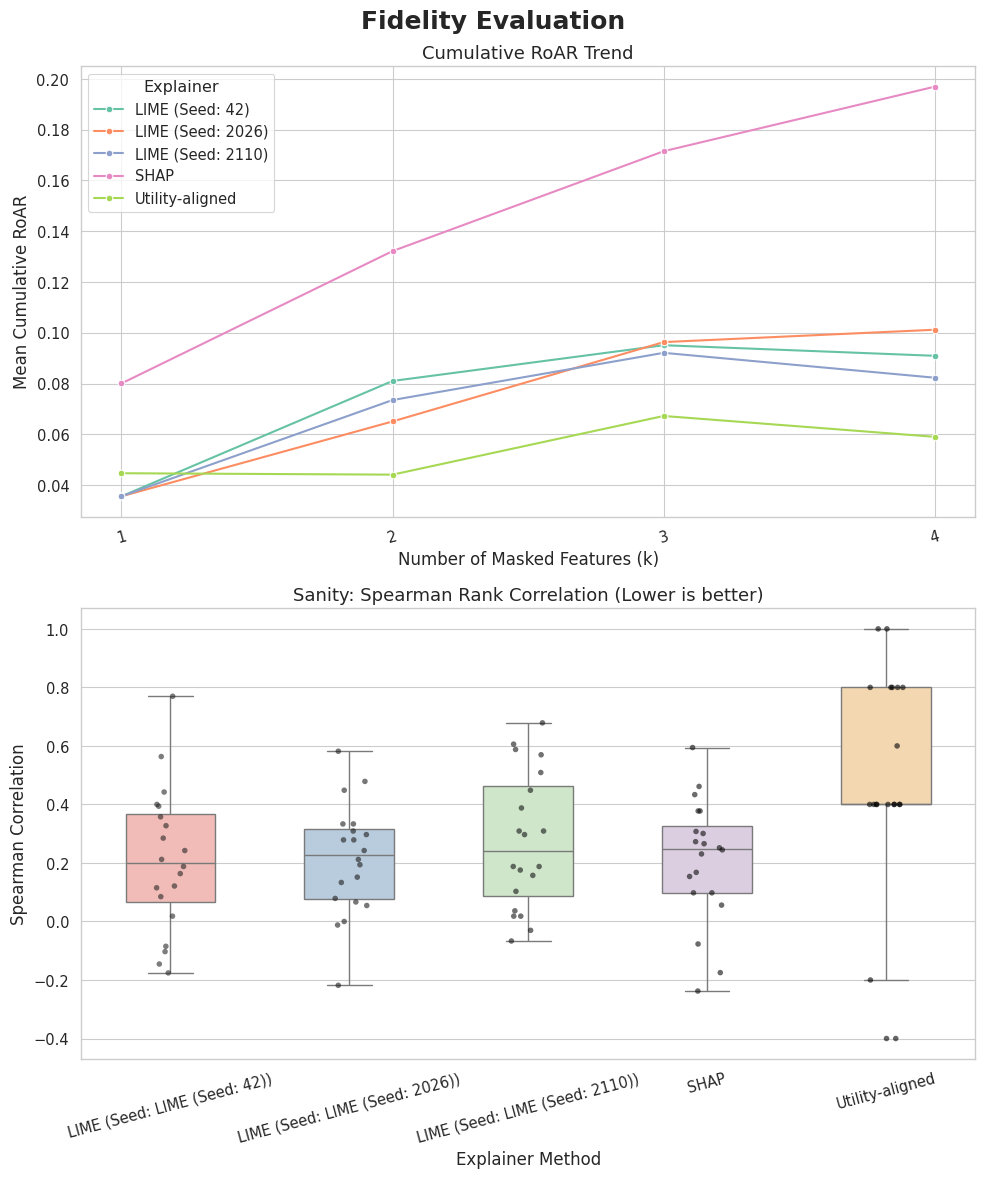

/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, p

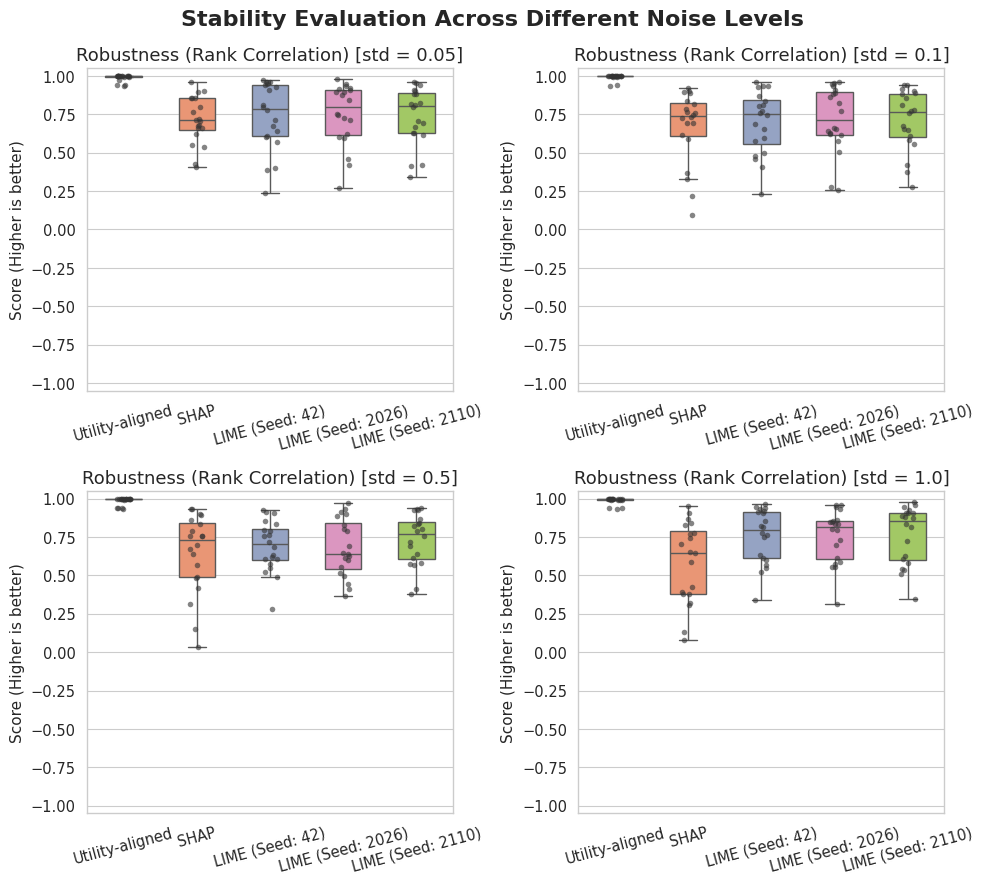

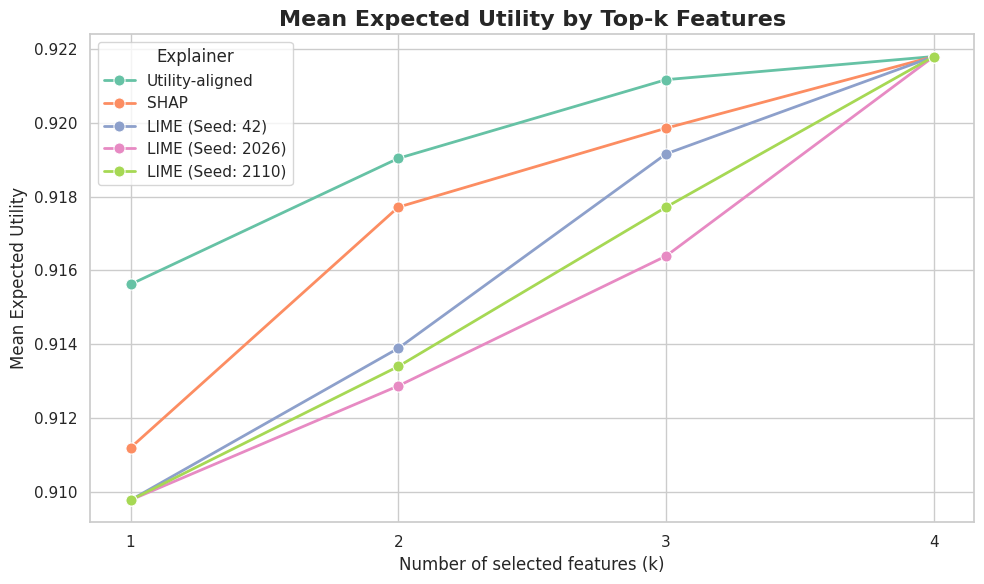

Running: adult_continue_better_2
Utility matrix:
[[0.05424467 0.53691474]
 [0.86283659 0.92426084]]


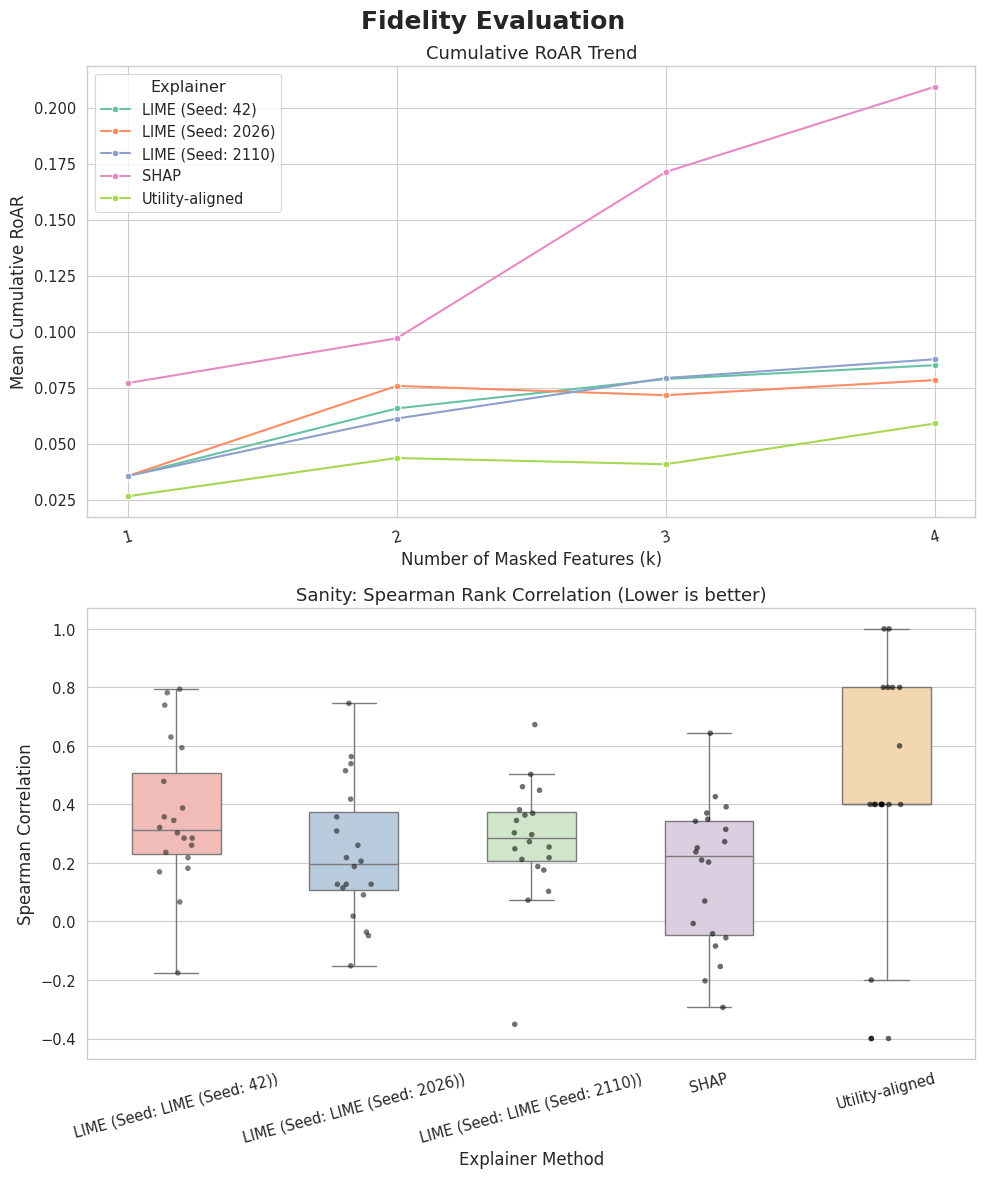

/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rob, x="Explainer", y="Score", ax=ax, p

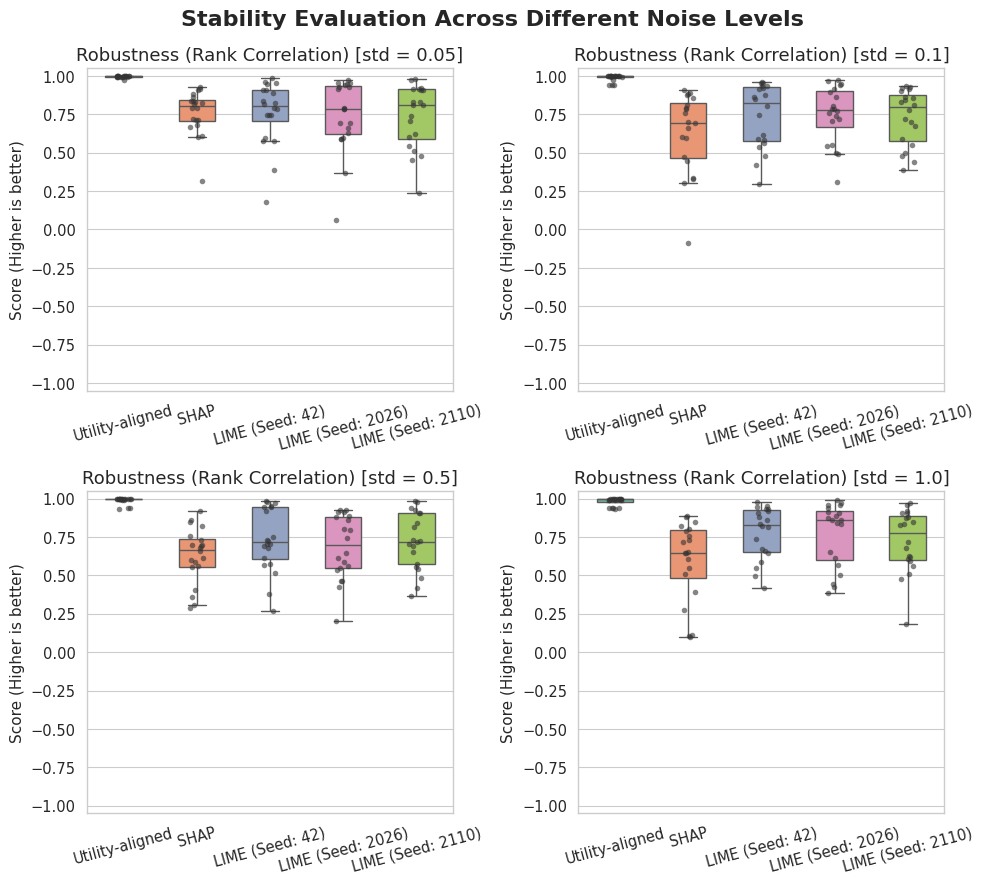

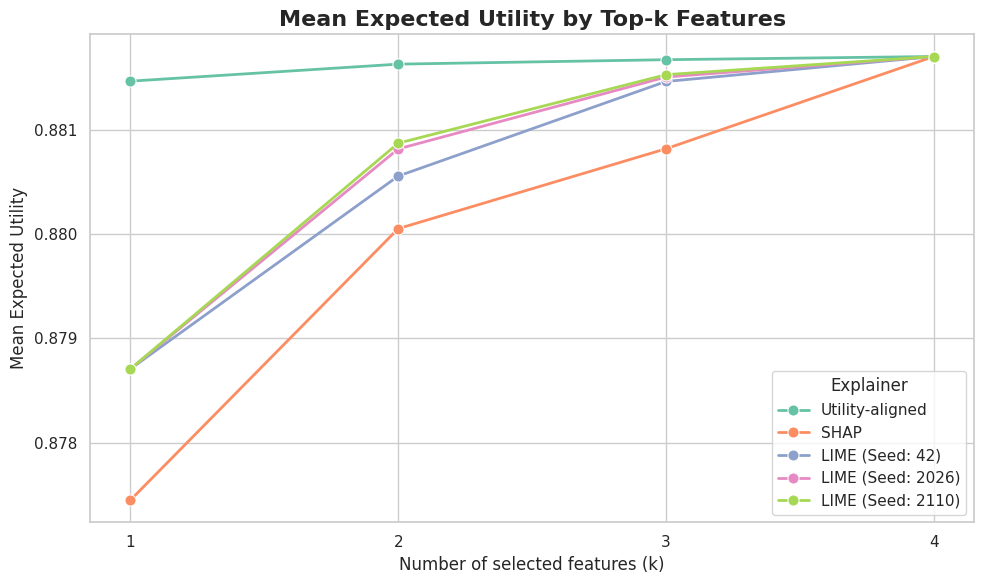

Running: adult_retire_better_3
Utility matrix:
[[0.99505058 0.84145153]
 [0.829279   0.66815466]]


KeyboardInterrupt: 

In [18]:
adult_lime_explainers_2 = dict()

# --------------------------------------------------
# Generate utility matrices
# --------------------------------------------------
base_matrices = generate_adult_utility_matrices(
    n_samples=10,
    seed=42,
    min_margin=0.15
)


# --------------------------------------------------
# LIME explainers
# --------------------------------------------------
for seed in used_seeds:
    adult_lime_explainer_2 = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_adult.values,
        feature_names=adult_features,
        class_names=adult_class_names,
        # categorical_features=adult_categorical_indices,
        # discretize_continuous=False,
        random_state=seed
    )

    adult_lime_explainers_2[seed] = adult_lime_explainer_2


# --------------------------------------------------
# SHAP explainer
# --------------------------------------------------
if isinstance(adult_model, xgb.XGBClassifier):
    adult_shap_explainer_2 = shap.Explainer(
        adult_model.predict,
        X_train_adult
    )
else:
    adult_shap_explainer_2 = shap.Explainer(adult_model)


# --------------------------------------------------
# Experiments
# --------------------------------------------------
results = dict()

# Counter per scenario
scenario_counters = {
    "retire_better": 0,
    "continue_better": 0,
    "symmetric": 0
}


for sample in base_matrices:

    title = sample["scenario"]
    utility_matrix = sample["utility_matrix"]

    i = scenario_counters[title]

    name = f"adult_{title}_{i}"

    print("=" * 70)
    print(f"Running: {name}")
    print("Utility matrix:")
    print(utility_matrix)
    print("=" * 70)

    adult_tester_2 = ExplainerTester(
        name=name,
        model=adult_model,
        features=adult_features,
        actions=adult_actions_2,
        causal_graph=adult_causal_2,
        utility_matrix=utility_matrix,
        X_train=X_train_adult,
        y_train=y_train_adult,
        X_val=X_val_adult,
        y_val=y_val_adult,
        X_test=X_test_adult,
        lime_explainers=adult_lime_explainers_2,
        shap_explainer=adult_shap_explainer_2,
        n_samples=20
    )

    results[name] = adult_tester_2.do_all_tests(
        display_test=True
    )

    scenario_counters[title] += 1